In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
import warnings
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,precision_score,recall_score,f1_score,accuracy_score
sys.path.append('../')
pd.options.mode.chained_assignment = None 



In [2]:
sns.color_palette("Set2").as_hex()[0:5]

['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#a6d854']

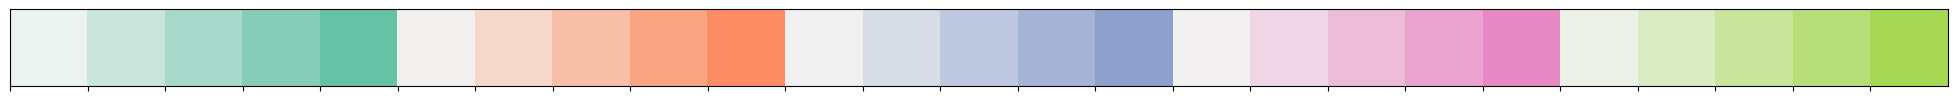

In [3]:
colors =sns.color_palette("Set2").as_hex()[0:5]
full_palette = sns.color_palette(colors)
sns.set_palette(full_palette)
cmap = LinearSegmentedColormap.from_list("custom_cmap", full_palette)
third_class = 'unknown'
expanded_palette = []

for color in colors:
    shades = sns.light_palette(color, n_colors=5)
    expanded_palette.extend(shades)

expanded_palette
sns.palplot(expanded_palette)

In [4]:
order = ['entering','exiting','entering-exiting','exiting-entering','unknown']

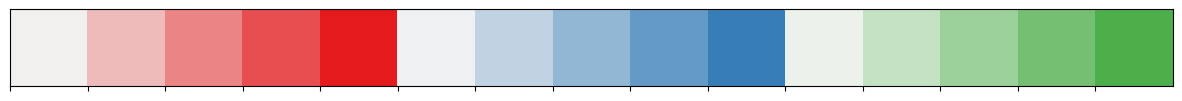

In [5]:
colors = sns.color_palette("Set1").as_hex()[0:3]
full_palette = sns.color_palette(colors)
expanded_palette2 = []
for color in colors:
    shades = sns.light_palette(color, n_colors=5)
    expanded_palette2.extend(shades)

sns.palplot(expanded_palette2)

In [6]:
palette = {
    "THRS_BIDIR":    expanded_palette2[4],
    "THRS_DOUB": expanded_palette2[3],
    "THRS_SING":expanded_palette2[2],
    "ANG_BIDIR": expanded_palette2[9],
    "ANG_SUM":expanded_palette2[8],
    "ANG_START":expanded_palette2[7],
    "ANG_END":expanded_palette2[6],
    "DISP_BIDIR":expanded_palette2[14],
    "DISP_FULL":expanded_palette2[13],
    "DISP_START":expanded_palette2[12],
    "DISP_END":expanded_palette2[11]
}

In [7]:
shortened = {
    "THRS_BIDIR": "THRS_BIDIR",
    "THRS_DOUBLE": "THRS_DOUB",
    "THRS_SINGLE": "THRS_SING",
    "BEE_ANG_BIDIR": "ANG_BIDIR",
    "BEE_ANG_SUM": "ANG_SUM",
    "BEE_ANG_START": "ANG_START",
    "BEE_ANG_END": "ANG_END",
    "DISP_BIDIR": "DISP_BIDIR",
    "DISP_START_END": "DISP_FULL",
    "DISP_START":"DISP_START",
    "DISP_END": "DISP_END"
}

In [47]:
algo_order = ["THRS_SINGLE","THRS_DOUBLE","ANG_START_OLD","ANG_END_OLD","BEE_ANG_SUM","BEE_ANG_START","BEE_ANG_END",
"DISP_START_END","DISP_START","DISP_END","THRS_BIDIR","DISP_BIDIR","BEE_ANG_BIDIR"]

In [9]:
distpalette = {
    "entering": expanded_palette[4],
    "exiting": expanded_palette[9],
    "entering-exiting": expanded_palette[14],
    "exiting-entering": expanded_palette[19],
    "unknown": expanded_palette[24]
}

In [11]:
vdf = pd.read_csv("5secondActivity.csv")
#vdf = vdf.drop_duplicates(subset=['track_starttime','track_tagid'], keep='last')

In [12]:
vdf['group_id'] = vdf['group_id'].astype(int)

In [13]:
#DISTANCE THRESHOLD
#used to classify an event as entering or exiting
#when two consecutive detections of the same event 
#have this distance in y position, they are utilized to predict
#the trajectory. If not then it checks the detection prior for
#the distance threshold, and continues doing so until it finds
#the last detection in the event or until it finds a distance
#of more than the threshold

t2 = 100

#ANG THRESHOLD
#used to generate angle ranges for classifying as exiting
#or entering

angle = 10


## APPROACHES

In [14]:
#APPROACHES 1 - INSIDE-OUTSIDE OR OUTSIDE-INSIDE

#two thresholds
def in_out(data):
    if data['cy'].iloc[0] < 450 and data['cy'].iloc[-1] > 600:
        return "entering"
    if data['cy'].iloc[0] > 450 and data['cy'].iloc[-1] < 600:
        return "exiting"
    return 'unknown'

#single threshold
def in_out_single(data):
    if data['track_starty'].iloc[0] < 770:
        str1 = 'outside'
    else:
        str1 = 'inside'

    if data['track_endy'].iloc[-1] < 770:
        str2 = "outside"
    else:
        str2 = "inside"
    track_shape = f'{str1}_{str2}'
    exiting = ['inside_outside']
    entering = ['outside_inside']
    if track_shape in exiting:
        return "exiting"
    elif track_shape in entering:
        return "entering"
    else:
        return "unknown"

#APPROACHES 2 ITERATE BACKWARDS DISPLACEMENT
def displacement(data):  

        #convert to numpy for speed
        y = data["cy"].to_numpy()
        #assign final and obtain all differences
        final = y[-1]
        diff = y - final

        #obtain all values where it surpasses the threshold
        idx = np.where(np.abs(diff) >= t2)[0]
        #extract only the last one
        cur = diff[idx[-1]] if idx.size else diff[0]

        if cur > 0:
            return "exiting"
        elif cur < 0:
            return "entering"
        else:
            return "unknown"

        
            

#APPROACHES 3 SUMMED DIRECTIONAL ANG

def angles(data):
    exit_min = 180 + angle
    exit_max = 360 - angle
    enter_min = angle
    enter_max = 180 - angle

    #obtain all angles of event
    coordinates = data['angle'].to_numpy()

    #obtain vector angle
    unit_dx = np.cos(np.deg2rad(coordinates))
    unit_dy = np.sin(np.deg2rad(coordinates))
    avg_x = np.average(unit_dx)
    avg_y = np.average(unit_dy)
    if avg_x == 0 and avg_y == 0:
        deg = 0
    elif avg_x == 0 and avg_y != 0:
        if avg_y > 0:
            deg = 270
        elif avg_y < 0:
            deg = 90
    else:
        # determine direction angle using arctan
        deg = np.rad2deg(np.arctan(avg_y/avg_x))
                    
        # since arctan limits are (-90,90), use coordinate directions to 
        # correct the angle to be within standard [0,360) range
        if avg_x > 0 and avg_y >= 0:
            deg = deg
        elif avg_x < 0 and avg_y >= 0:
            deg = 180 + deg
        elif avg_x < 0 and avg_y < 0:
            deg = deg + 180
        elif avg_x > 0 and avg_y < 0:
            deg = 360 + deg

    if deg >= exit_min and deg <= exit_max:
        return 'exiting'
    elif deg >= enter_min and deg <= enter_max:
        return 'entering'
    else:
        return 'unknown'

#subfunction of previous application, except with one
#single angle instead

def getangle(coordinates):
    exit_min = 180 + angle
    exit_max = 360 - angle
    enter_min = angle
    enter_max = 180 - angle

    #normalize angle from -180 to 180 to 0 to 360
    deg = coordinates % 360

    if deg >= exit_min and deg <= exit_max:
        return 'exiting'
    elif deg >= enter_min and deg <= enter_max:
        return 'entering'
    else:
        return 'unknown'

#APPROACHES 4 LAST DIRECTIONAL ANG

def lastangle(data):
   
    secondhalf = data.iloc[len(data) // 2:]        
    return angles(secondhalf)


#APPROACHES 5 INIT - FINAL DISPLACEMENT
def displacementinit(data):            
        coordinates = data['cy']
        
        final = coordinates.iloc[-1]
        init = coordinates.iloc[0]

        if init > final:
            return 'exiting'
        elif final > init:
            return 'entering'
        else:
            return 'unknown'             

#APPROACHES 6 FIRST DIRECTIONAL ANG

def firstangle(data):

    
    firsthalf = data.iloc[:len(data)//2]
    return angles(firsthalf)


#APPROACHES 7 ITERATE FORWARDS DISPLACEMENT
def displacement2(data):            
        #convert to numpy for speed
        y = data["cy"].to_numpy()
        #assign first and obtain all differences
        first = y[0]
        diff = y - first

        #obtain all values where it surpasses the threshold
        idx = np.where(np.abs(diff) >= t2)[0]
        #extract only the first one
        cur = diff[idx[0]] if idx.size else diff[0]

        if cur < 0:
            return 'exiting'
        elif cur > 0:
            return 'entering'
        else:
            return 'unknown'
            


####CLASSIFICATION AS ENTERING-EXITING OR EXITING-ENTERING

#APPROACHES 1 ITERATE BACKWARDS AND FORWARDS DISPLACEMENT
#COMBINES FORWARD ITERATION AND BACKWARDS ITERATION
def displacementbackforth(data):   


        string2 = displacement(data)
        string = displacement2(data)

        #if both directions are the same, return value
        #else return compound event
        return string if string == string2 else f"{string}-{string2}"
        

#APPROACHES 2 FIRST AND LAST DIRECTIONAL ANG
#COMBINES FIRST ANG AND LAST ANG

def lastfirstangle(data):

    coordinates = data['angle'].iloc[-1]

    string2 = getangle(coordinates)

    coordinates = data['angle'].iloc[0]

    string = getangle(coordinates)

    #if both directions are the same, return value
    #else return compound event
    return string if string == string2 else f"{string}-{string2}"


#APPROACHES 3 THRESHOLD BIDIR
def in_out2(data):
    if data['cy'].iloc[0] < 450 and data['cy'].iloc[-1] > 600:
        return "entering"
    if data['cy'].iloc[0] > 450 and data['cy'].iloc[-1] < 600:
        return "exiting"
    if data['cy'].iloc[0] < 450 and data['cy'].iloc[-1] < 450:
        return "entering-exiting"
    if data['cy'].iloc[0] > 600 and data['cy'].iloc[-1] > 600:
        return "exiting-entering"
    return 'unknown'


##OLD VERSIONS


def lastangleOLD(data):
   
    coordinates = data['angle'].iloc[-1]

    return getangle(coordinates)


def firstangleOLD(data):
   
    coordinates = data['angle'].iloc[0]

    return getangle(coordinates)

In [15]:
#read cheatsheet of all cases

cheatsheet = pd.read_csv("5seconds_20260406_234425.csv")

#scores that will be used in the analysis

scores = ["precision","recall","f1-score","accuracy"]
compound = ['entering-exiting','exiting-entering','unknown']

#cheatsheet = cheatsheet[cheatsheet['ambiguousflag'] != 'x'].reset_index()
mapping = {'DU':'exiting-entering','UD':'entering-exiting','D':'exiting','U':'entering'}
cheatsheet['event'] = cheatsheet['event'].map(mapping)

In [15]:
cheatsheet

,group_id,event,ambiguousflag,short_interruption,complex,comment,track_id,filename,video,datetime,tagid,mergethreshold,eventid
0,0,NaN,x,NaN,NaN,end_on_ramp,6110,5second/track_06110_5s.png,5_02_R_190807150000.cfr.mp4,22:31.3,0,5s,0__6110
1,1,exiting,NaN,NaN,NaN,NaN,15926,5second/track_15926_5s.png,30_02_R_190808150000.cfr.mp4,45:27.4,10,5s,10__15926
2,2,entering,NaN,NaN,NaN,NaN,15368,5second/track_15368_5s.png,6_02_R_190807160000.cfr.mp4,50:43.8,25,5s,25__15368
3,3,exiting,NaN,NaN,NaN,NaN,10358,5second/track_10358_5s.png,29_02_R_190808140000.cfr.mp4,37:53.6,33,5s,33__10358
4,4,exiting,NaN,NaN,NaN,NaN,8103,5second/track_08103_5s.png,27_02_R_190808120000.cfr.mp4,25:23.0,40,5s,40__8103
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1312,1312,NaN,x,NaN,NaN,stay_at_entrance,20988,5second/track_20988_5s.png,31_02_R_190808160000.cfr.mp4,40:15.6,2962,5s,2962__20988
1313,1313,NaN,x,NaN,NaN,NaN,23480,5second/track_23480_5s.png,31_02_R_190808160000.cfr.mp4,47:56.0,2962,5s,2962__23480_23490
1314,1314,exiting,NaN,NaN,NaN,NaN,11732,5second/track_11732_5s.png,6_02_R_190807160000.cfr.mp4,41:01.9,2973,5s,2973__11732
1315,1315,entering,NaN,NaN,NaN,NaN,7364,5second/track_07364_5s.png,2_02_R_190807120000.cfr.mp4,26:16.8,2997,5s,2997__7364


In [16]:
#function that obtains all scores from classification report for each algorithm

def calculate_scores(matrix,cheatsheet,labels):
    scores = {}
    for column in matrix.columns:
        col = matrix[column]
        report = classification_report(
        cheatsheet,
        col,
        target_names=labels,
        labels=labels,
        output_dict = True
        )
        report['accuracy']= accuracy_score(cheatsheet, col)
        scores[column] = report
    return scores

In [17]:
#unpacks dict to turn into melted df

def flatten_dict(scores,labels):
    new_dict = {'algo':[],'score':[],'class':[],'value':[]}
    for algo in scores.keys():
        #c = class
        for c in scores[algo].keys():
            if c == "accuracy":
                new_dict['algo'].append(algo)
                new_dict['score'].append('accuracy')
                new_dict['class'].append(pd.NA)
                new_dict['value'].append(scores[algo]['accuracy'])
            elif c in labels:
                for score in scores[algo][c].keys():
                    new_dict['algo'].append(algo)
                    new_dict['score'].append(score)
                    new_dict['value'].append(scores[algo][c][score])
                    new_dict['class'].append(c)
    df = pd.DataFrame.from_dict(new_dict)
    return df

In [18]:
#generates graphs of all scores
#label is used for the name of the file i.e. 'simple', 'compound'
def generate_graphs(the_dict,label):
    for s in scores:
        df = the_dict[the_dict['score'] == s]
        if s == "accuracy":
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.barplot(df,x="algo",y="value",hue="algo",palette=palette,ax=ax,alpha=1.0,saturation=1.0)           
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.set_yticks(np.linspace(0,1,11))
            ax.grid(True, axis="y", color="gray", alpha=0.5) 
            ax.set_axisbelow(True)
            ax.set_xlabel("Algorithm",fontsize=20)
            ax.set_ylabel("Accuracy",fontsize=20)
            ax.margins(x=0.1)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            #ax.legend(fontsize=16, title_fontsize=14)
            ax.tick_params(axis='both', labelsize=16)
            ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')
            fig.savefig(f"{label}-{s}.png",bbox_inches='tight')
        else:
            algo_order = list(df["algo"].drop_duplicates())
            plot = sns.FacetGrid(
                df, col="class", hue="algo",
                height=5, col_wrap=2, aspect=1.5, palette=palette
            )
            plot.map(plt.bar, "algo", "value", edgecolor="white", linewidth=0.1)
            
            axes = list(plot.axes.flat)
            n = len(axes)
            ncols = 2
            if len(axes) == 3:
                show_xticks = {1,2}
            elif len(axes) == 4:
                show_xticks = {2,3}
            else:
                show_xticks = {0,1}
            
            for i, ax in enumerate(axes):
                ax.set_yticks(np.linspace(0, 1, 11))
                ax.grid(True, axis="y", color="gray", alpha=0.5)
                ax.set_axisbelow(True)
                ax.margins(x=0.1)
            
                if i in show_xticks:
                    ax.tick_params(axis="x", labelbottom=True)
                    ax.set_xticks(range(len(algo_order)))
                    ax.set_xticklabels(algo_order, rotation=45, ha="right")
                else:
                    ax.tick_params(axis="x", labelbottom=False)
                ax.tick_params(axis='both', labelsize=16)
                ax.set_xlabel("Algorithm",fontsize=20)
                ax.set_ylabel("Score",fontsize=20)
            #ax.legend(fontsize=16, title_fontsize=14)
            ax.tick_params(axis='both', labelsize=16)
            plot.set_axis_labels(x_var="Algorithm", y_var=s.title())
            plot.fig.subplots_adjust(bottom=0.25)
            plot.savefig(f"{label}-{s}.png",bbox_inches='tight') 

In [19]:
#generates graphs of all scores
#label is used for the name of the file i.e. 'simple', 'compound'
def generate_sidegraphs(the_dict,label):
        metrics = ["recall","precision"]
        df = the_dict[the_dict['score'].isin(metrics)]
        algo_order = list(df["algo"].drop_duplicates())
        plot = sns.catplot(
            data=df,
            kind="bar",
            x="algo",
            y="value",
            hue="class",
            col="score",
            col_wrap=2,
            height=5,
            aspect=1.5,
            palette=distpalette,
            saturation=1
        )

        plot.set_titles("{col_name}")
        for ax in plot.axes.flat:
            title = ax.get_title()
            ax.set_title(title.title(),fontsize=20) 
            ax.set_yticks(np.linspace(0,1,11))
            ax.grid(True, axis="y", color="gray", alpha=0.5)
            ax.set_axisbelow(True)
            ax.margins(x=0.1)
            ax.set_xticks(range(len(algo_order)))
            ax.set_xticklabels(algo_order, rotation=45, ha="right")
            ax.tick_params(axis="x", labelbottom=True)
            ax.margins(x=0.1)
            ax.set_xlabel("Algorithm", fontsize=20)
            ax.set_ylabel("", fontsize=20)
            ax.tick_params(axis='x', labelsize=16)
            ax.tick_params(axis='y', labelsize=16)
            

        plot.tick_params(axis='x', labelrotation=45)
        plot.set(ylabel='')
        plot.set(xlabel='Algorithm')
        plot.legend.set_title("Class")
        plot.legend.set_title("Class", prop={'size': 18})  
        plot.legend.set_bbox_to_anchor((1.05, 0.5)) 
        for text in plot.legend.texts:
            text.set_fontsize(16) 

        plot.fig.subplots_adjust(bottom=0.25)
        plot.savefig(f"{label}-side.png",bbox_inches='tight') 
        
        
        '''plot.tick_params(axis='x', labelrotation=45)
            ax = plot.ax
            plot.legend.set_title("Class")
            ax.set_yticks(np.linspace(0,1,11))
            ax.grid(True, axis="y", color="gray", alpha=0.5)
            ax.set_axisbelow(True)
            ax.margins(x=0.1)
            ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')
            #ax.legend(fontsize=16, title_fontsize=14)
            ax.tick_params(axis='both', labelsize=16)
            plot.legend.set_title("Class")
            plot.legend.set_title("Class", prop={'size': 18})  
            plot.legend.set_bbox_to_anchor((1.05, 0.5)) 
            for text in plot.legend.texts:
                text.set_fontsize(16) 
            plot.set_axis_labels(x_var="Algorithm", y_var=s.title())
            plot.fig.subplots_adjust(bottom=0.25)
            plot.savefig(f"{label}-{s}-side.png",bbox_inches='tight') 



            plot = sns.FacetGrid(
                df, col="class", hue="algo",
                height=5, col_wrap=2, aspect=1.5, palette=palette
            )'''

In [20]:
#generates graphs of distribution of classes
#label is used for the name of the file i.e. 'simple', 'compound'
def generate_dist(the_matrix,label):
    the_df = []
    for c in the_matrix.columns:
        column = the_matrix[c]
        values = column.value_counts()
        df = values.rename("count").reset_index()
        df["algo"] = c
        df = df.rename(columns={df.columns[0]:'event'})
        the_df.append(df)
    full_df = pd.concat(the_df, ignore_index=True)

    stacked = full_df.pivot_table(
    index="algo", 
    columns="event", 
    values="count",
    fill_value=0
    )
    stacked = stacked.reindex(the_matrix.columns)
    num_cols = stacked.shape[1]
    if(num_cols > 3):
        stacked = stacked.reindex(columns=order)

    fig, ax = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(stacked))

    for event in stacked.columns:
        values = stacked[event].values

        bars = ax.bar(
            stacked.index,
            values,
            bottom=bottom,
            edgecolor="white",
            label=event,
            color=distpalette.get(event)
        )

        bottom += values

    ax.legend(
    title="Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=16, title_fontsize=18
    )

    ax.tick_params(axis='both', labelsize=16)
    
    ax.tick_params(axis='x', labelrotation=45)
    ax.grid(True, axis="y", color="gray", alpha=0.5) 
    ax.set_ylabel("Count",fontsize=20)
    ax.set_axisbelow(True)
    ax.set_xlabel("Algorithm",fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')
    ax.margins(x=0.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    fig.savefig(f"{label}-count.png",bbox_inches='tight',bbox_extra_artists=(ax.get_legend(),)) 
    plt.show()

    

In [23]:
#generate all classifications

labels = ['entering','exiting','entering-exiting','exiting-entering']
for_matrix = {}

functions = {
    'THRS_DOUBLE': in_out,
    'THRS_SINGLE': in_out_single,
    'DISP_START_END': displacementinit,
    'ANG_START_OLD': firstangleOLD,
    'ANG_END_NEW': lastangleOLD,
    'BEE_ANG_SUM': angles,
    'THRS_BIDIR':in_out2,
    'DISP_START': displacement2,
    'DISP_END': displacement,
    'BEE_ANG_START': firstangle,
    'BEE_ANG_END': lastangle,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}
functions = {k: functions[k] for k in algo_order if k in functions}

for APPROACHES, func in functions.items():
    for_matrix[APPROACHES] = []
    
for index, row in cheatsheet.iterrows():
    event = row['event']
    line = row['group_id']
    detections = vdf[vdf['group_id'] == line]

    unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix[APPROACHES].append(result)



In [24]:
def generateAcc(matrix,cheatsheet,labels):
    for col in matrix:
        column = matrix[col]
        print(col)
        print(classification_report(cheatsheet['event'],column,labels=labels,target_names=labels))
        print("ACCURACY")
        print(accuracy_score(cheatsheet['event'],column))

In [25]:
matrix = pd.DataFrame.from_dict(for_matrix)


Misclassified compound events (run if not removing noise events)

In [24]:
matrix['tagid'] = cheatsheet['tagid']
matrix['datetime'] = cheatsheet['datetime']

In [25]:
#DISP_START_END
UDindex = cheatsheet[cheatsheet['event'] == 'entering-exiting'].index
DUindex = cheatsheet[cheatsheet['event'] == 'exiting-entering'].index
DSE = matrix['DISP_START_END']
DSE.loc[UDindex].value_counts()
#DSE.loc[DUindex].value_counts()


DISP_START_END
entering    71
exiting     58
Name: count, dtype: int64

In [176]:
matrix['diff'] = (matrix.groupby('tagid')['DISP_START_END'].transform(lambda s: s + '-' + s.shift(-1)))

In [178]:
s = matrix.loc[matrix['diff'] == 'entering-exiting', 'diff']
len(s.loc[s.index.intersection(UDindex)])

23

In [179]:
s = matrix.loc[matrix['diff'] == 'exiting-entering', 'diff']
len(s.loc[s.index.intersection(DUindex)])

15

In [27]:
#DISP_START_END
UDindex = cheatsheet[cheatsheet['comment'] == 'stay_at_exit'].index
DUindex = cheatsheet[cheatsheet['comment'] == 'stay_at_entrance'].index
DSE = matrix['DISP_START_END']
#DSE.loc[UDindex].value_counts()
DSE.loc[DUindex].value_counts()


DISP_START_END
exiting     56
entering     6
Name: count, dtype: int64

In [181]:
#BEE_ANGLE_SUM

BAS = matrix['BEE_ANG_SUM']
#BAS.loc[UDindex].value_counts()
BAS.loc[DUindex].value_counts()


BEE_ANG_SUM
exiting     140
entering     42
unknown      18
Name: count, dtype: int64

In [183]:
matrix['diff'] = (matrix.groupby('tagid')['BEE_ANG_SUM'].transform(lambda s: s + '-' + s.shift(-1)))
s = matrix.loc[matrix['diff'] == 'entering-exiting', 'diff']
len(s.loc[s.index.intersection(UDindex)])

16

In [184]:
s = matrix.loc[matrix['diff'] == 'exiting-entering', 'diff']
len(s.loc[s.index.intersection(DUindex)])

19

In [60]:
#read cheatsheet of all cases

cheatsheet = pd.read_csv("5seconds_20260406_234425.csv")
ambiguous = ['TRUE','x']
cheatsheet = cheatsheet[~cheatsheet['ambiguousflag'].isin(ambiguous)].dropna(subset=['event']).reset_index()
mapping = {'DU':'exiting-entering','UD':'entering-exiting','D':'exiting','U':'entering'}
cheatsheet['event'] = cheatsheet['event'].map(mapping)

#generate all classifications

labels = ['entering','exiting','entering-exiting','exiting-entering']
for_matrix = {}

functions = {
    'THRS_DOUBLE': in_out,
    'THRS_SINGLE': in_out_single,
    'DISP_START_END': displacementinit,
    'ANG_START_OLD': firstangleOLD,
    'ANG_END_OLD': lastangleOLD,
    'BEE_ANG_SUM': angles,
    'THRS_BIDIR':in_out2,
    'DISP_START': displacement2,
    'DISP_END': displacement,
    'BEE_ANG_START': firstangle,
    'BEE_ANG_END': lastangle,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}
functions = {k: functions[k] for k in algo_order if k in functions}

for APPROACHES, func in functions.items():
    for_matrix[APPROACHES] = []
    
for index, row in cheatsheet.iterrows():
    event = row['event']
    line = row['group_id']
    detections = vdf[vdf['group_id'] == line]

    unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix[APPROACHES].append(result)



In [61]:
cheatsheet['event'].unique()

array(['exiting', 'entering', 'exiting-entering', 'entering-exiting'],
      dtype=object)

In [62]:
matrix = pd.DataFrame.from_dict(for_matrix)


classification graph generation and such

In [63]:
matrix

,THRS_SINGLE,THRS_DOUBLE,ANG_START_OLD,ANG_END_OLD,BEE_ANG_SUM,BEE_ANG_START,BEE_ANG_END,DISP_START_END,DISP_START,DISP_END,THRS_BIDIR,DISP_BIDIR,BEE_ANG_BIDIR
0,exiting,exiting,exiting,unknown,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,unknown
1,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering
2,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting
3,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting
4,entering,entering,unknown,entering,unknown,unknown,unknown,entering,entering,entering,entering,entering,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1279,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting
1280,unknown,unknown,unknown,entering,unknown,unknown,unknown,exiting,exiting,exiting,exiting-entering,exiting,unknown
1281,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,exiting,entering,exiting,exiting-entering,exiting
1282,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering,entering


In [64]:
labels = ['entering','exiting']
cheatsheet_simple = cheatsheet[~cheatsheet['event'].isin(compound)]
simple_matrix = matrix.iloc[:, 0:10].loc[cheatsheet_simple.index]
score = calculate_scores(simple_matrix,cheatsheet_simple['event'],labels)
simple_dict = flatten_dict(score,labels)
generateAcc(simple_matrix,cheatsheet_simple,labels)

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.99      0.99      0.99       335
     exiting       1.00      0.99      1.00       545

   micro avg       1.00      0.99      0.99       880
   macro avg       1.00      0.99      0.99       880
weighted avg       1.00      0.99      0.99       880

ACCURACY
0.990909090909091
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.99      0.98      0.99       335
     exiting       1.00      0.99      1.00       545

   micro avg       1.00      0.99      0.99       880
   macro avg       1.00      0.99      0.99       880
weighted avg       1.00      0.99      0.99       880

ACCURACY
0.9875
ANG_START_OLD
              precision    recall  f1-score   support

    entering       0.98      0.61      0.75       335
     exiting       0.98      0.95      0.97       545

   micro avg       0.98      0.82      0.89       880
   macro avg       0.98      0.78      0.86    

In [65]:
angle = 30

#read cheatsheet of all cases

cheatsheet = pd.read_csv("5seconds_20260406_234425.csv")
ambiguous = ['TRUE','x']
cheatsheet = cheatsheet[~cheatsheet['ambiguousflag'].isin(ambiguous)].dropna(subset=['event']).reset_index()
mapping = {'DU':'exiting-entering','UD':'entering-exiting','D':'exiting','U':'entering'}
cheatsheet['event'] = cheatsheet['event'].map(mapping)

#generate all classifications

labels = ['entering','exiting','entering-exiting','exiting-entering']
for_matrix = {}

functions = {
    'THRS_DOUBLE': in_out,
    'THRS_SINGLE': in_out_single,
    'DISP_START_END': displacementinit,
    'ANG_START_OLD': firstangleOLD,
    'ANG_END_OLD': lastangleOLD,
    'BEE_ANG_SUM': angles,
    'THRS_BIDIR':in_out2,
    'DISP_START': displacement2,
    'DISP_END': displacement,
    'BEE_ANG_START': firstangle,
    'BEE_ANG_END': lastangle,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}
functions = {k: functions[k] for k in algo_order if k in functions}

for APPROACHES, func in functions.items():
    for_matrix[APPROACHES] = []
    
for index, row in cheatsheet.iterrows():
    event = row['event']
    line = row['group_id']
    detections = vdf[vdf['group_id'] == line]

    unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix[APPROACHES].append(result)


matrix = pd.DataFrame.from_dict(for_matrix)



In [66]:
labels = ['entering','exiting']
cheatsheet_simple = cheatsheet[~cheatsheet['event'].isin(compound)]
simple_matrix = matrix.iloc[:, 0:10].loc[cheatsheet_simple.index]
score = calculate_scores(simple_matrix,cheatsheet_simple['event'],labels)
simple_dict = flatten_dict(score,labels)
generateAcc(simple_matrix,cheatsheet_simple,labels)

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.99      0.99      0.99       335
     exiting       1.00      0.99      1.00       545

   micro avg       1.00      0.99      0.99       880
   macro avg       1.00      0.99      0.99       880
weighted avg       1.00      0.99      0.99       880

ACCURACY
0.990909090909091
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.99      0.98      0.99       335
     exiting       1.00      0.99      1.00       545

   micro avg       1.00      0.99      0.99       880
   macro avg       1.00      0.99      0.99       880
weighted avg       1.00      0.99      0.99       880

ACCURACY
0.9875
ANG_START_OLD
              precision    recall  f1-score   support

    entering       0.98      0.61      0.75       335
     exiting       0.98      0.95      0.97       545

   micro avg       0.98      0.82      0.89       880
   macro avg       0.98      0.78      0.86    

In [67]:
simple_dict_copy = simple_dict.copy()
simple_dict_copy['algo'] = simple_dict['algo'].map(shortened) 

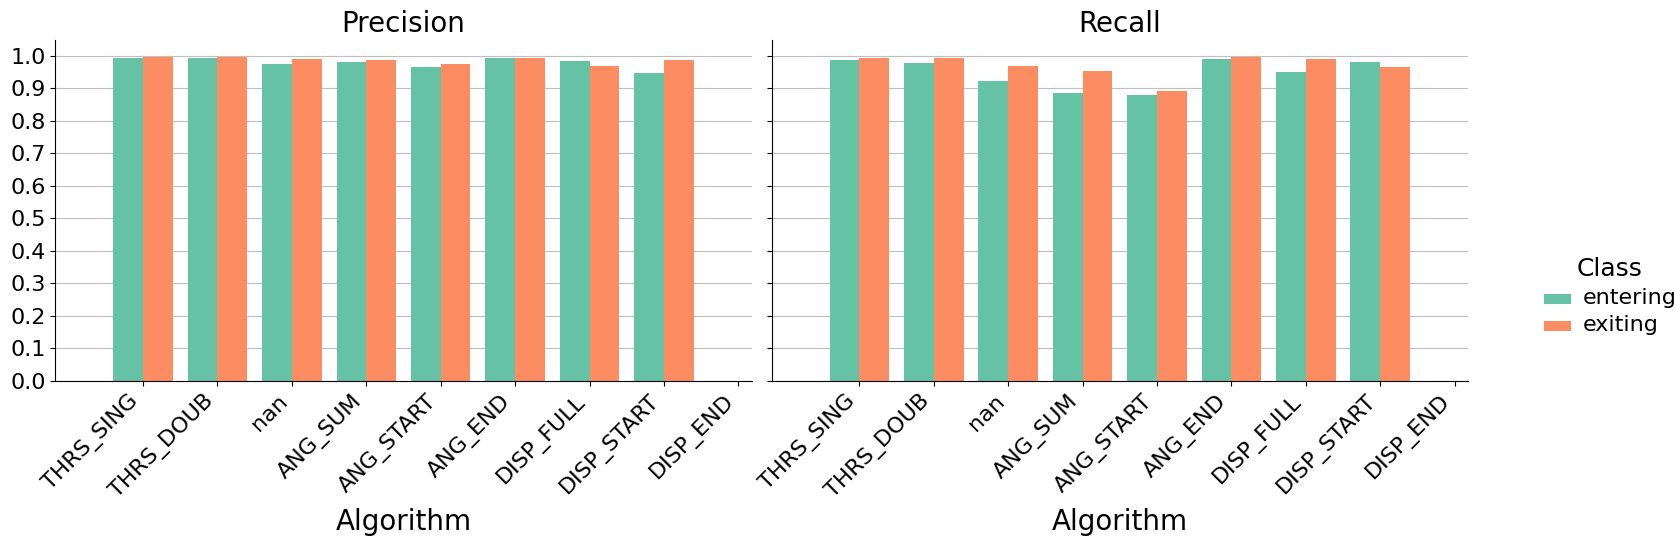

In [68]:
generate_sidegraphs(simple_dict_copy,"simple")

C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


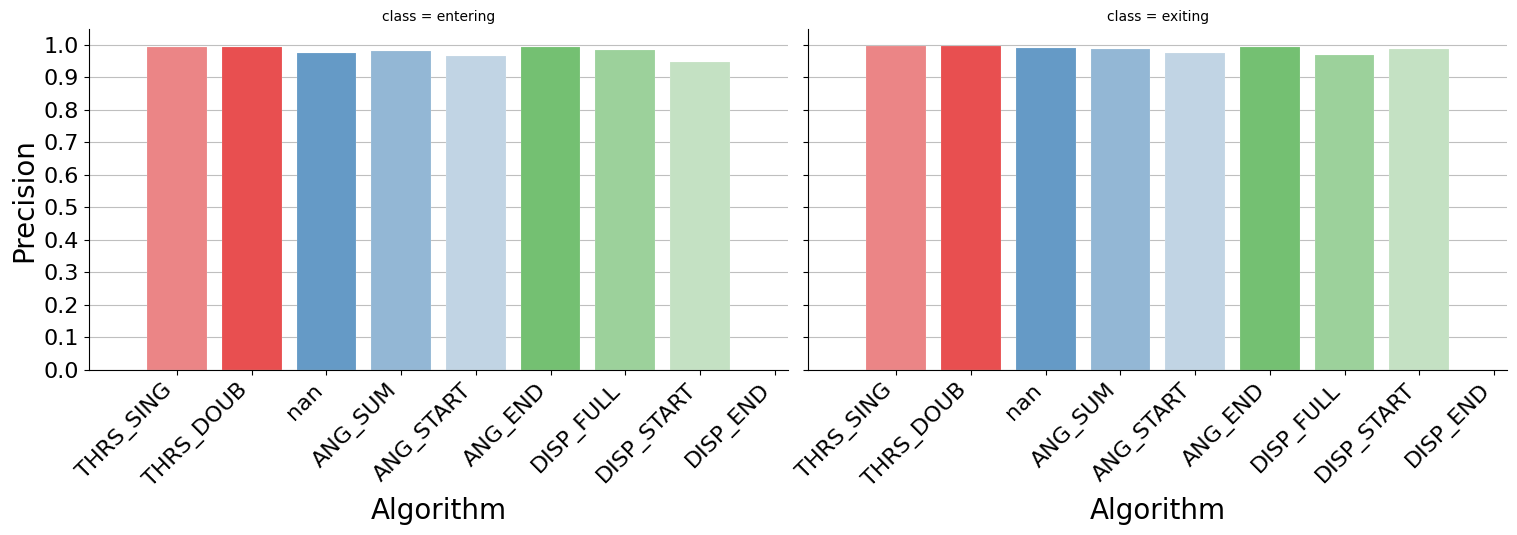

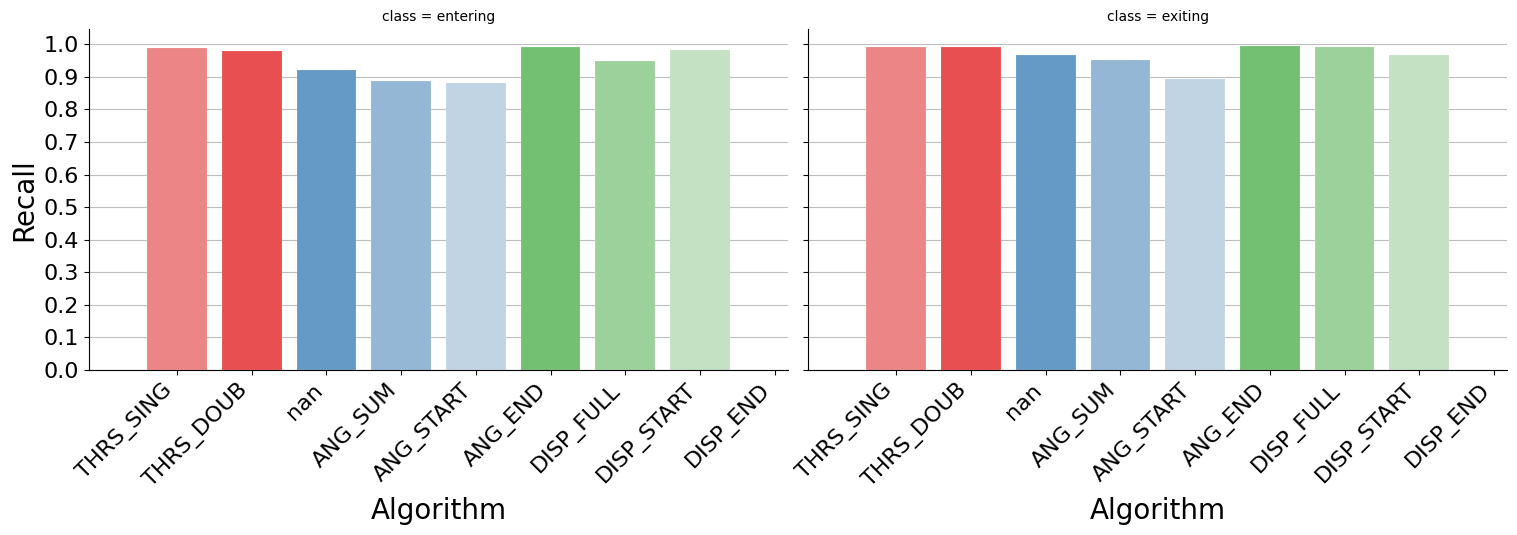

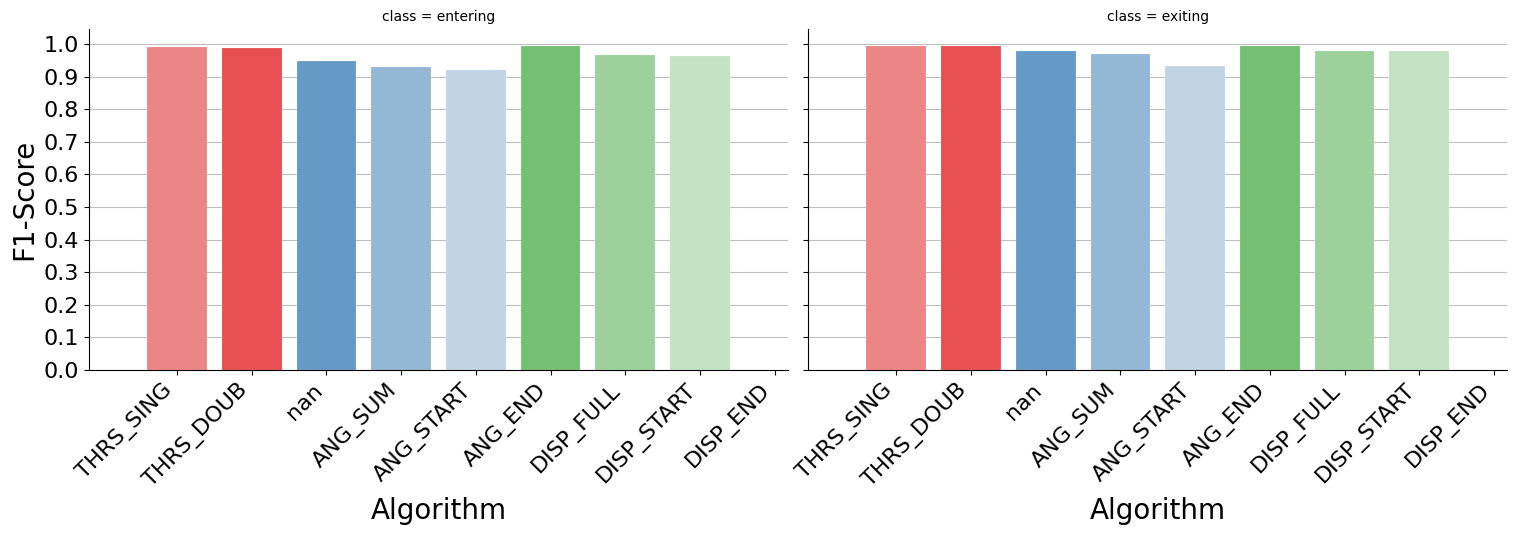

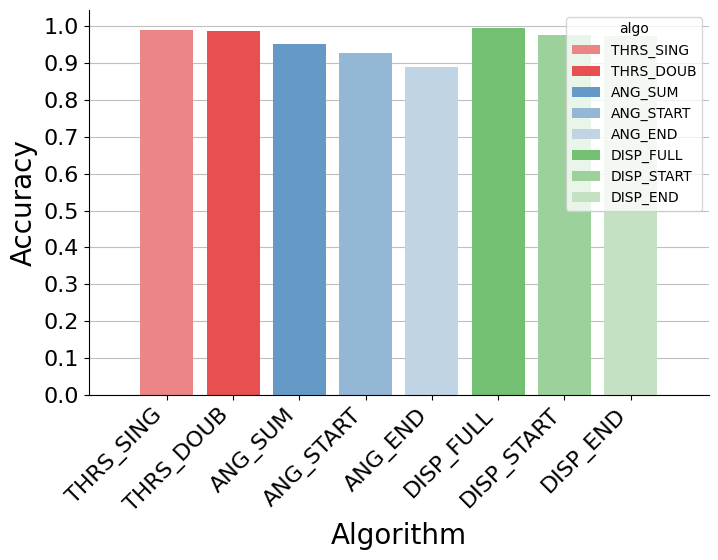

In [69]:
generate_graphs(simple_dict_copy,"simple")


C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\244971825.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


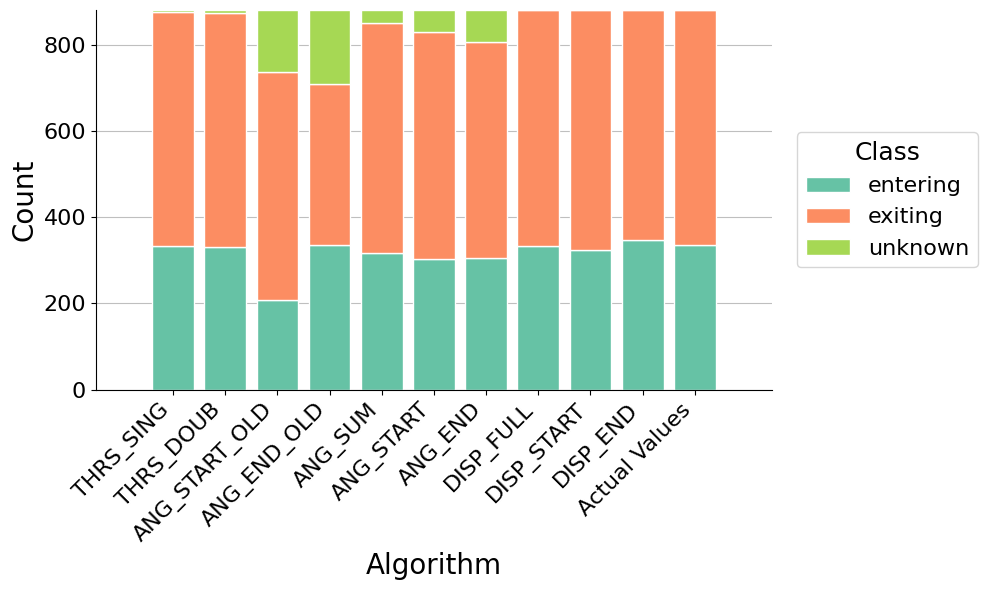

In [70]:
simple_matrix.rename(columns=shortened, inplace=True)
simple_matrix['Actual Values'] = cheatsheet_simple['event']
generate_dist(simple_matrix,"simple")

Unknown added as a third class

In [138]:
labels = ['entering','exiting','unknown']
cheatsheet_three = cheatsheet.replace(compound,'unknown')
three_matrix = matrix.iloc[:, 0:8]
score = calculate_scores(three_matrix,cheatsheet_three['event'],labels)
three_dict = flatten_dict(score,labels)
three_dict['algo'] = three_dict['algo'].map(shortened) 
generateAcc(three_matrix,cheatsheet_three,labels)

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.98      0.99      0.99       306
     exiting       0.99      0.99      0.99       518
     unknown       0.99      0.97      0.98       280

    accuracy                           0.99      1104
   macro avg       0.99      0.99      0.99      1104
weighted avg       0.99      0.99      0.99      1104

ACCURACY
0.9864130434782609
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.98      0.99      0.99       306
     exiting       0.99      0.99      0.99       518
     unknown       0.99      0.97      0.98       280

    accuracy                           0.99      1104
   macro avg       0.99      0.99      0.99      1104
weighted avg       0.99      0.99      0.99      1104

ACCURACY
0.9864130434782609
BEE_ANG_SUM
              precision    recall  f1-score   support

    entering       0.74      0.96      0.84       306
     exiting       0.76      0.98    

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

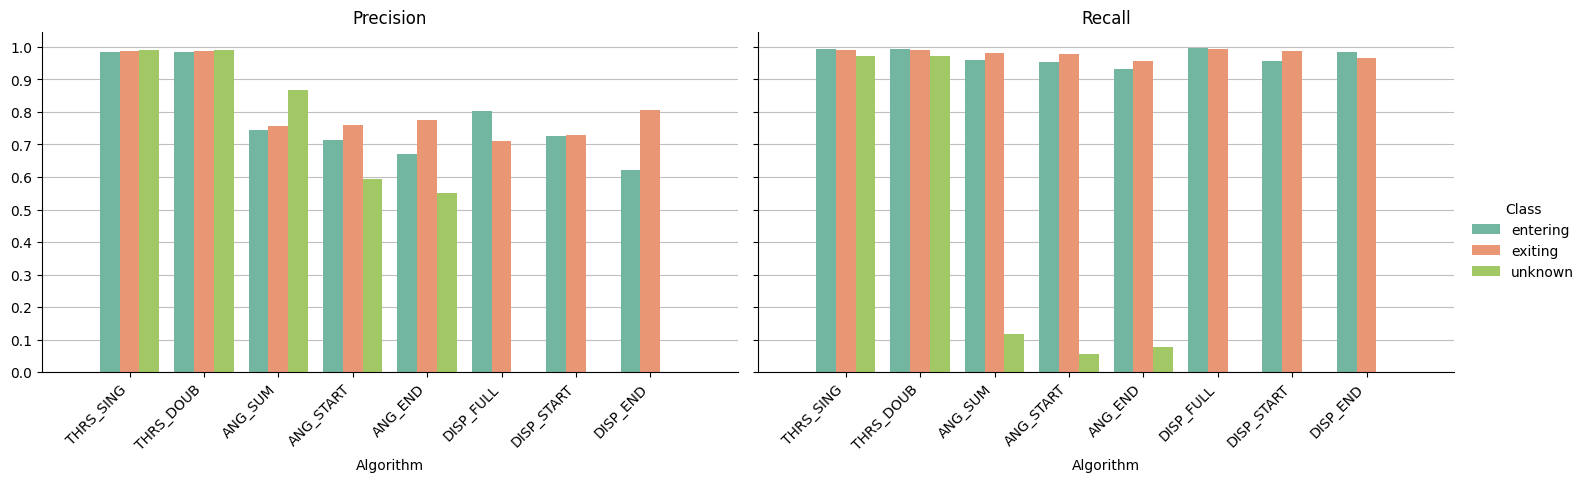

In [139]:
generate_sidegraphs(three_dict,"three")

C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\2787845209.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\2787845209.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


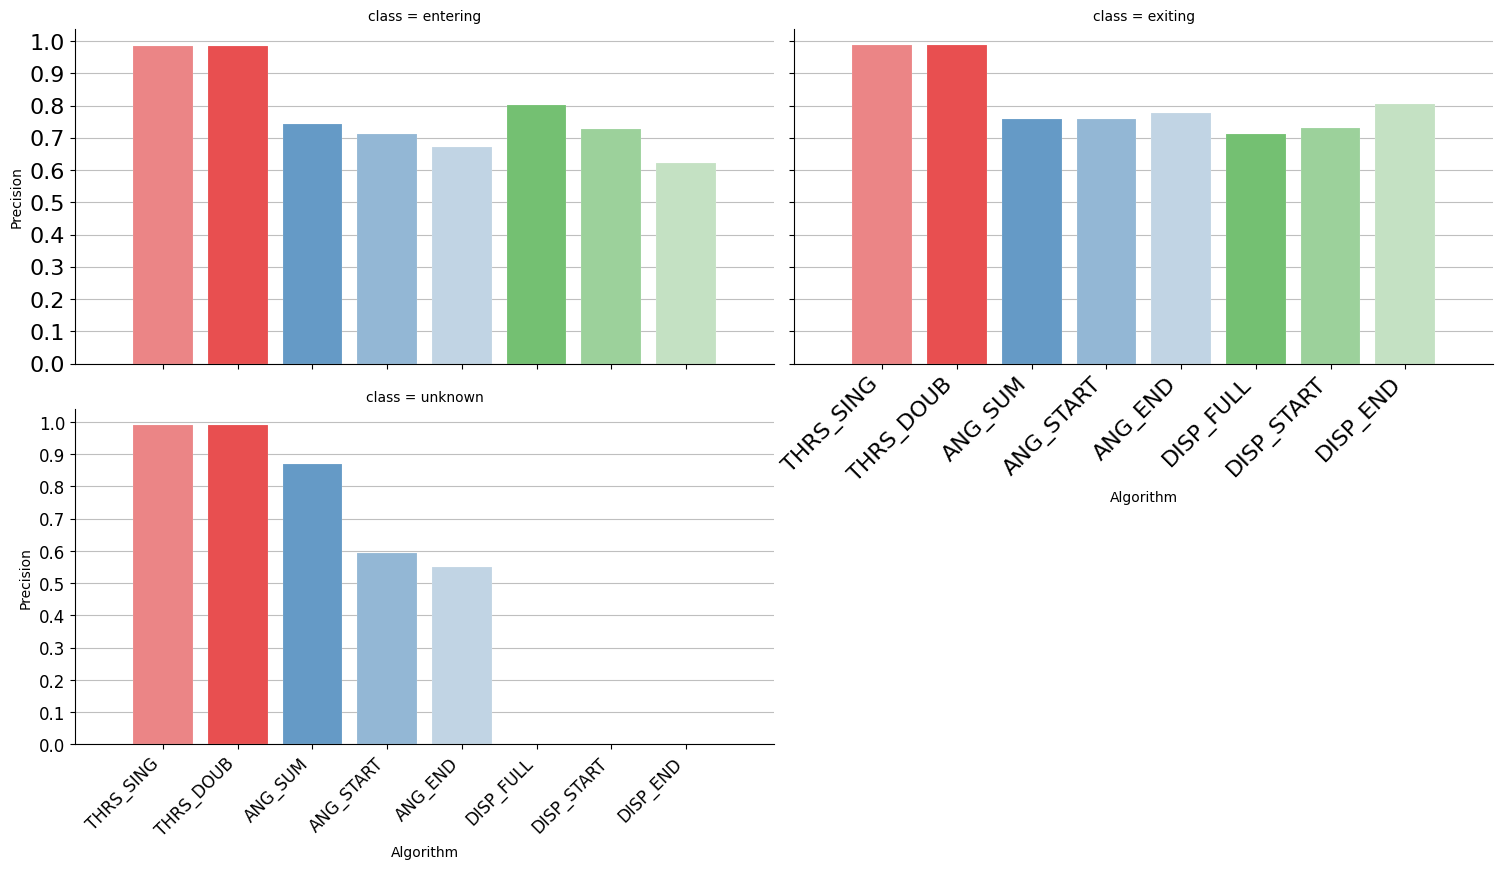

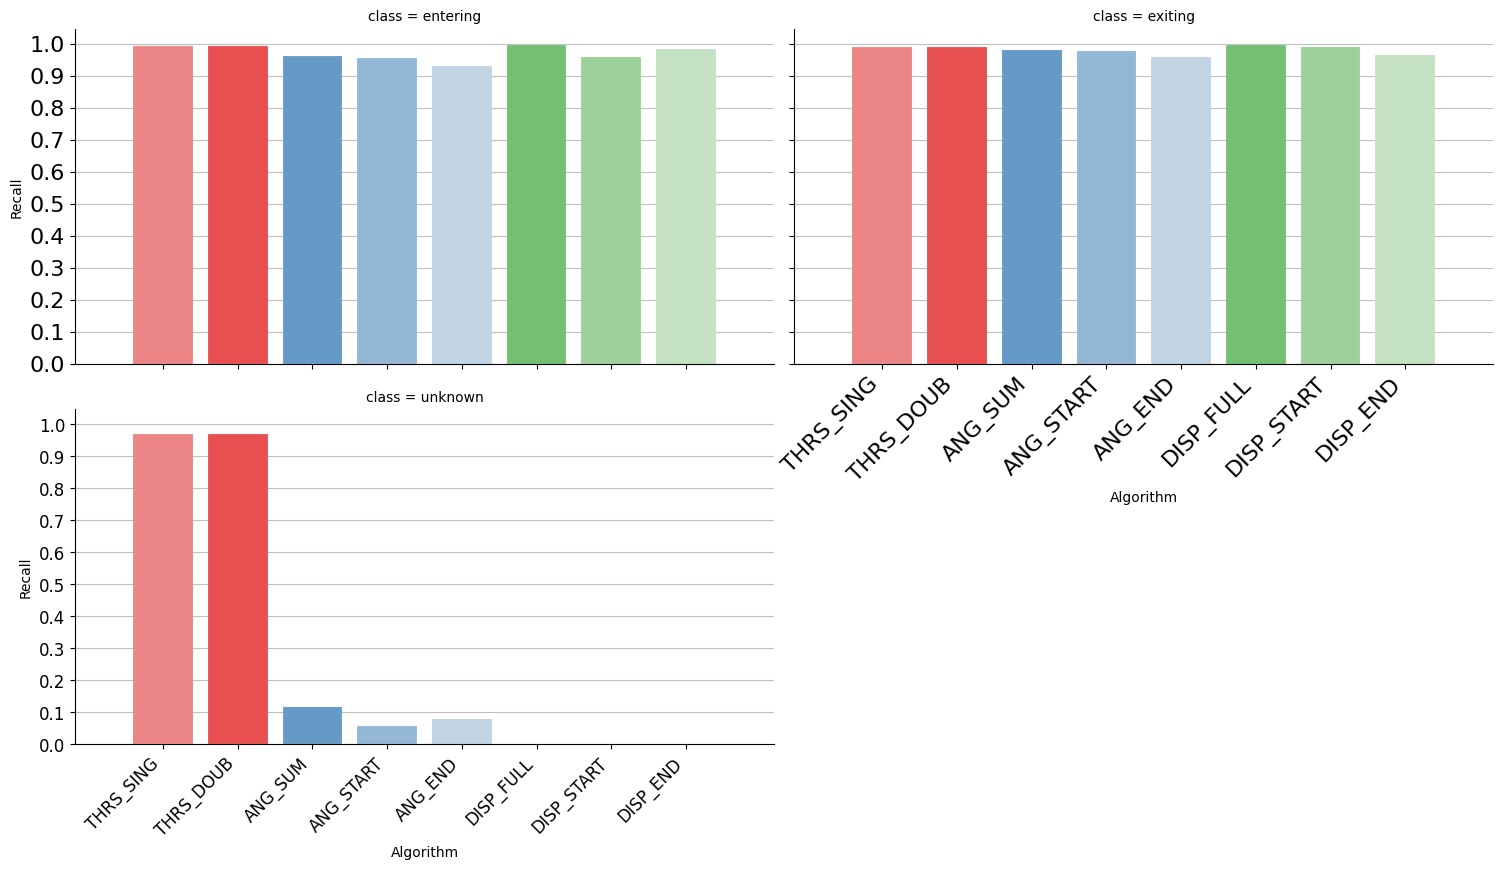

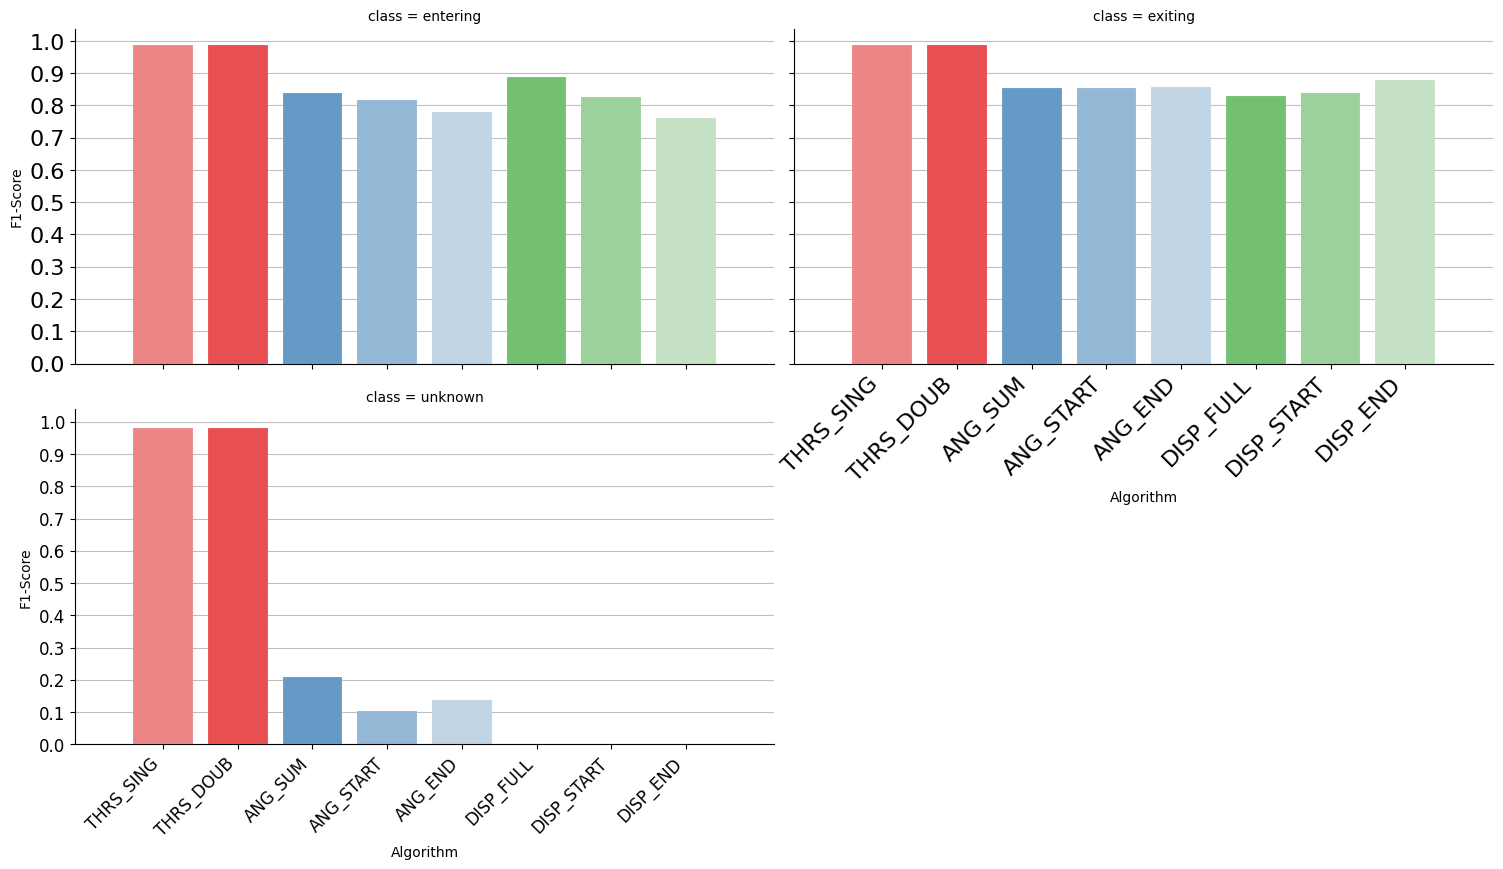

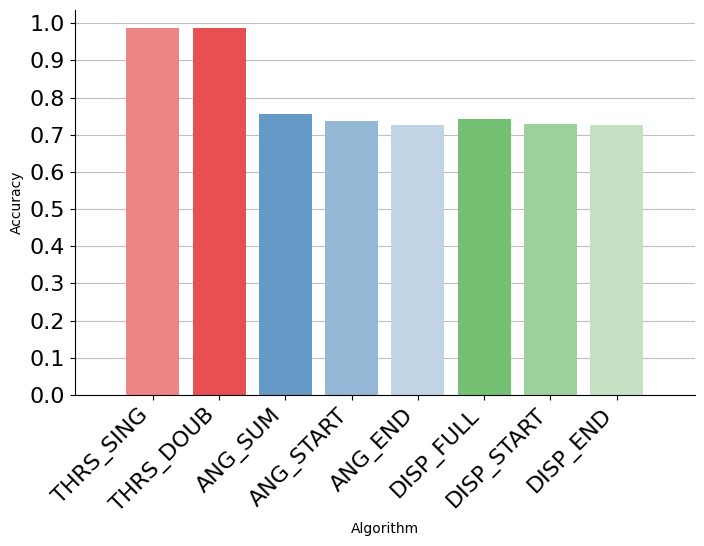

In [140]:
generate_graphs(three_dict,"three")

C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\1029863662.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


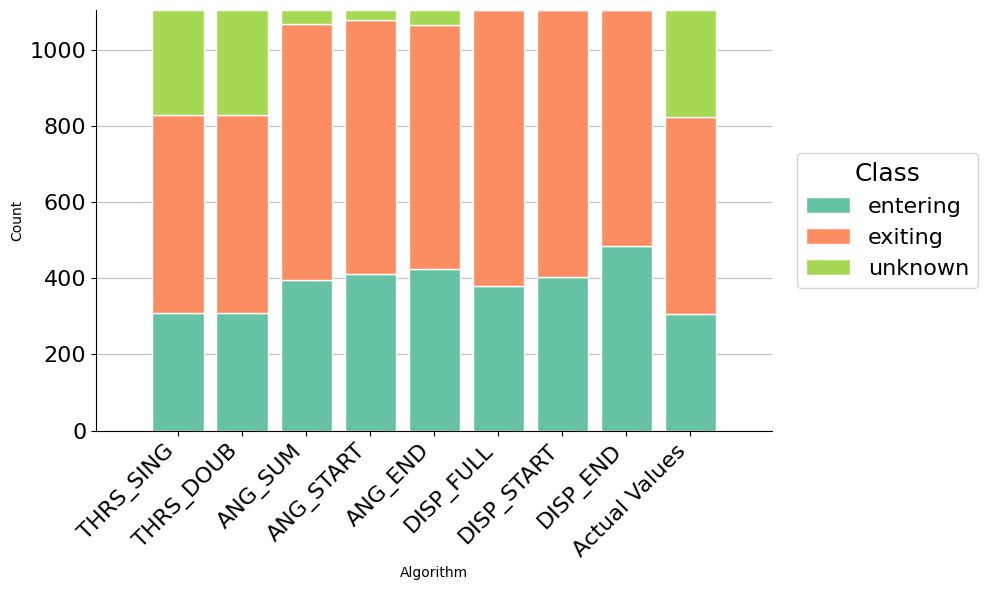

In [141]:
three_matrix.rename(columns=shortened, inplace=True)
three_matrix['Actual Values'] = cheatsheet_three['event']
generate_dist(three_matrix,"three")

Compound cases

In [144]:
labels = ['entering','exiting'] + compound
cheatsheet_compound = cheatsheet.copy()
compound_matrix = matrix.iloc[:, 8:]
score = calculate_scores(compound_matrix,cheatsheet_compound['event'],labels)
compound_dict = flatten_dict(score,labels)
generateAcc(compound_matrix,cheatsheet,labels)

THRS_BIDIR
                  precision    recall  f1-score   support

        entering       0.98      0.99      0.99       306
         exiting       0.99      0.99      0.99       518
entering-exiting       1.00      0.99      1.00       110
exiting-entering       0.98      0.96      0.97       170
         unknown       0.00      0.00      0.00         0

        accuracy                           0.99      1104
       macro avg       0.79      0.79      0.79      1104
    weighted avg       0.99      0.99      0.99      1104

ACCURACY
0.9864130434782609
DISP_BIDIR
                  precision    recall  f1-score   support

        entering       0.98      0.94      0.96       306
         exiting       0.97      0.96      0.96       518
entering-exiting       0.93      0.91      0.92       110
exiting-entering       0.86      0.95      0.90       170
         unknown       0.00      0.00      0.00         0

        accuracy                           0.95      1104
       macro avg 

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

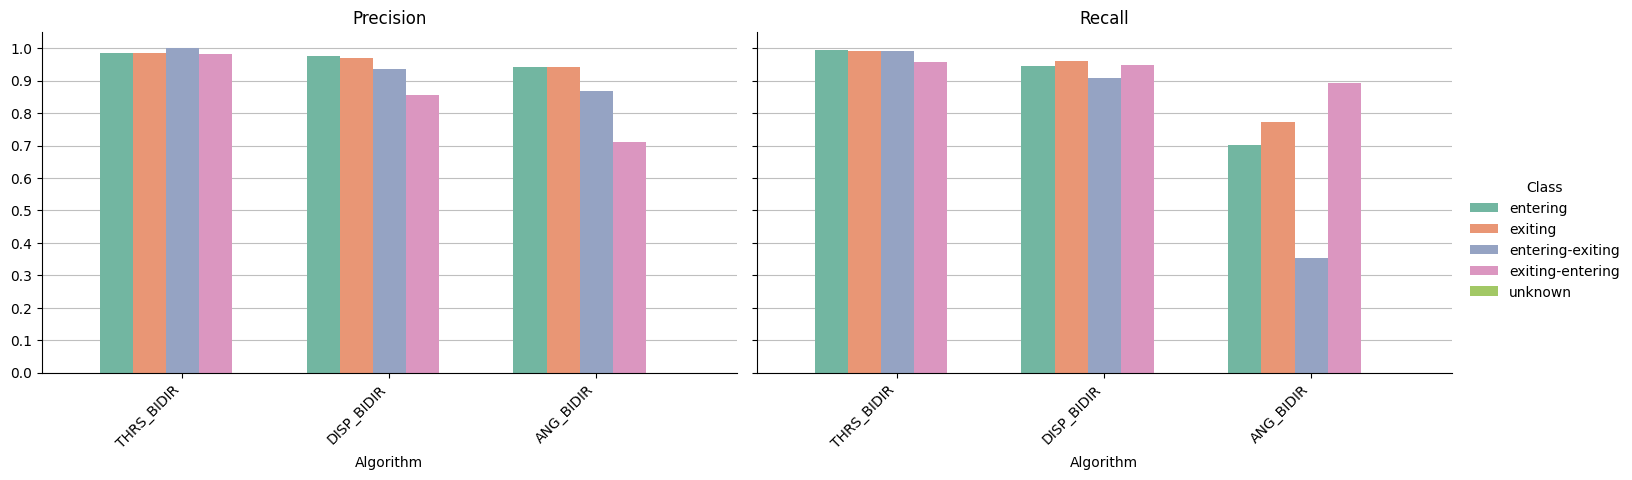

In [145]:
compound_dict_copy = compound_dict.copy()
compound_dict_copy['algo'] = compound_dict['algo'].map(shortened) 
generate_sidegraphs(compound_dict_copy,"compound")

C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\2787845209.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\2787845209.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


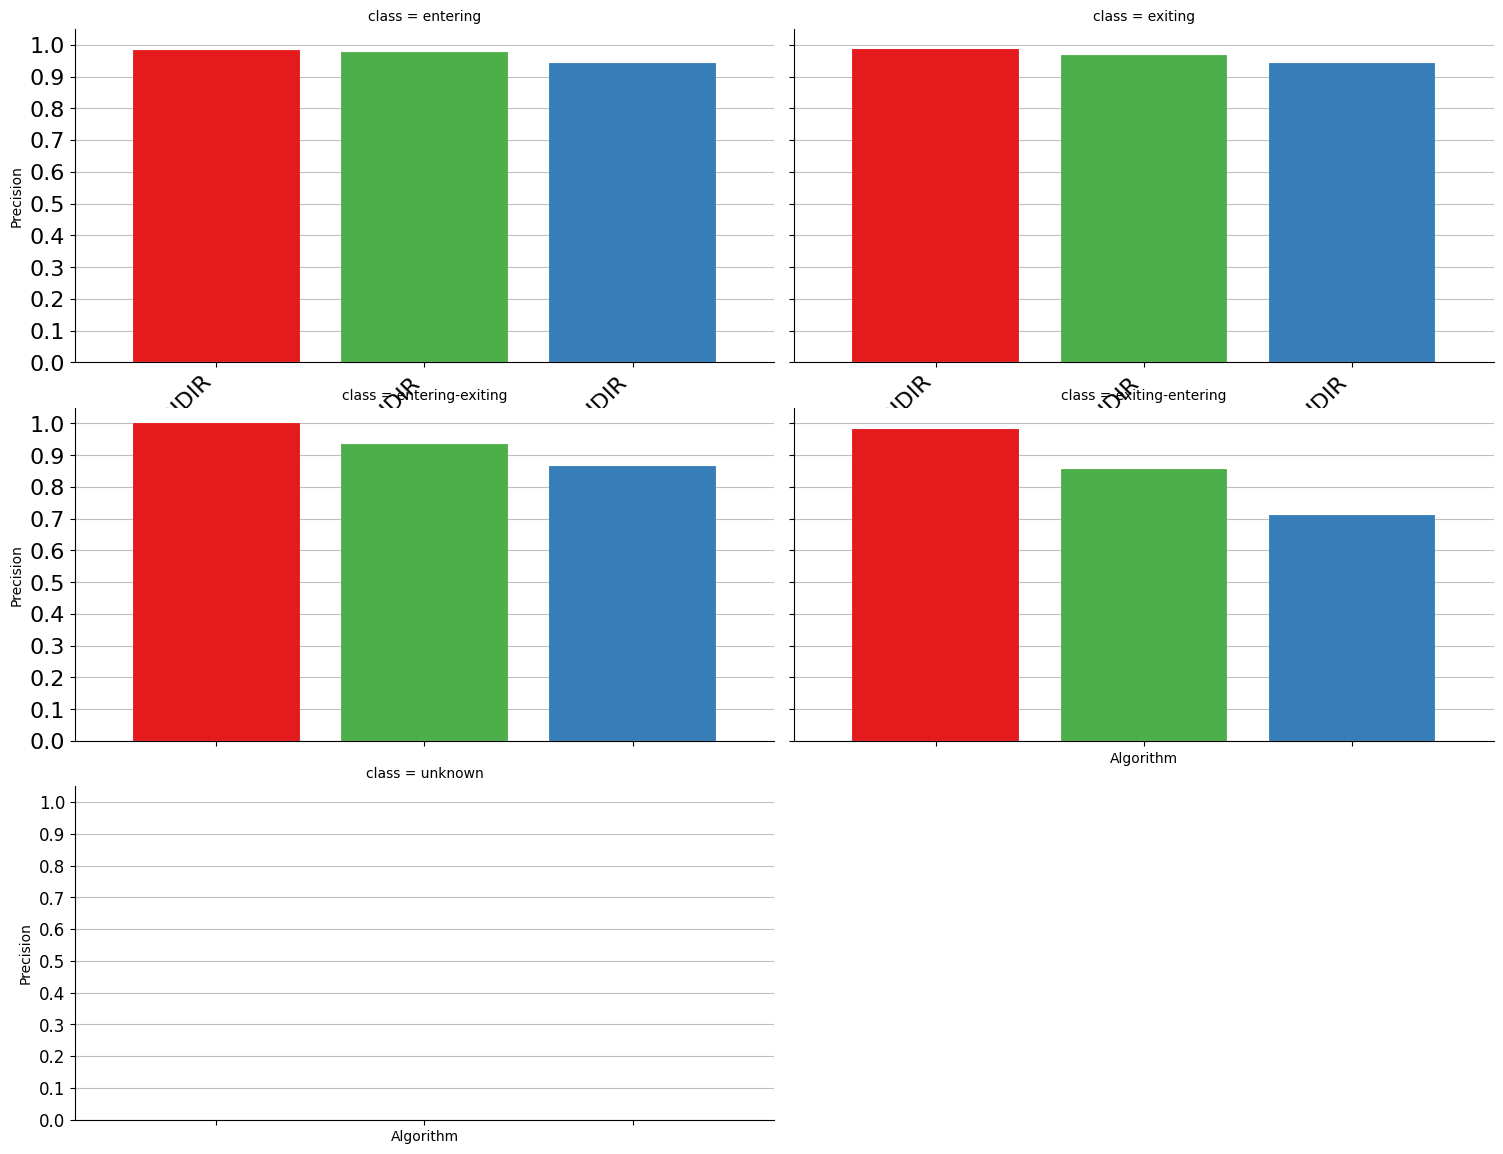

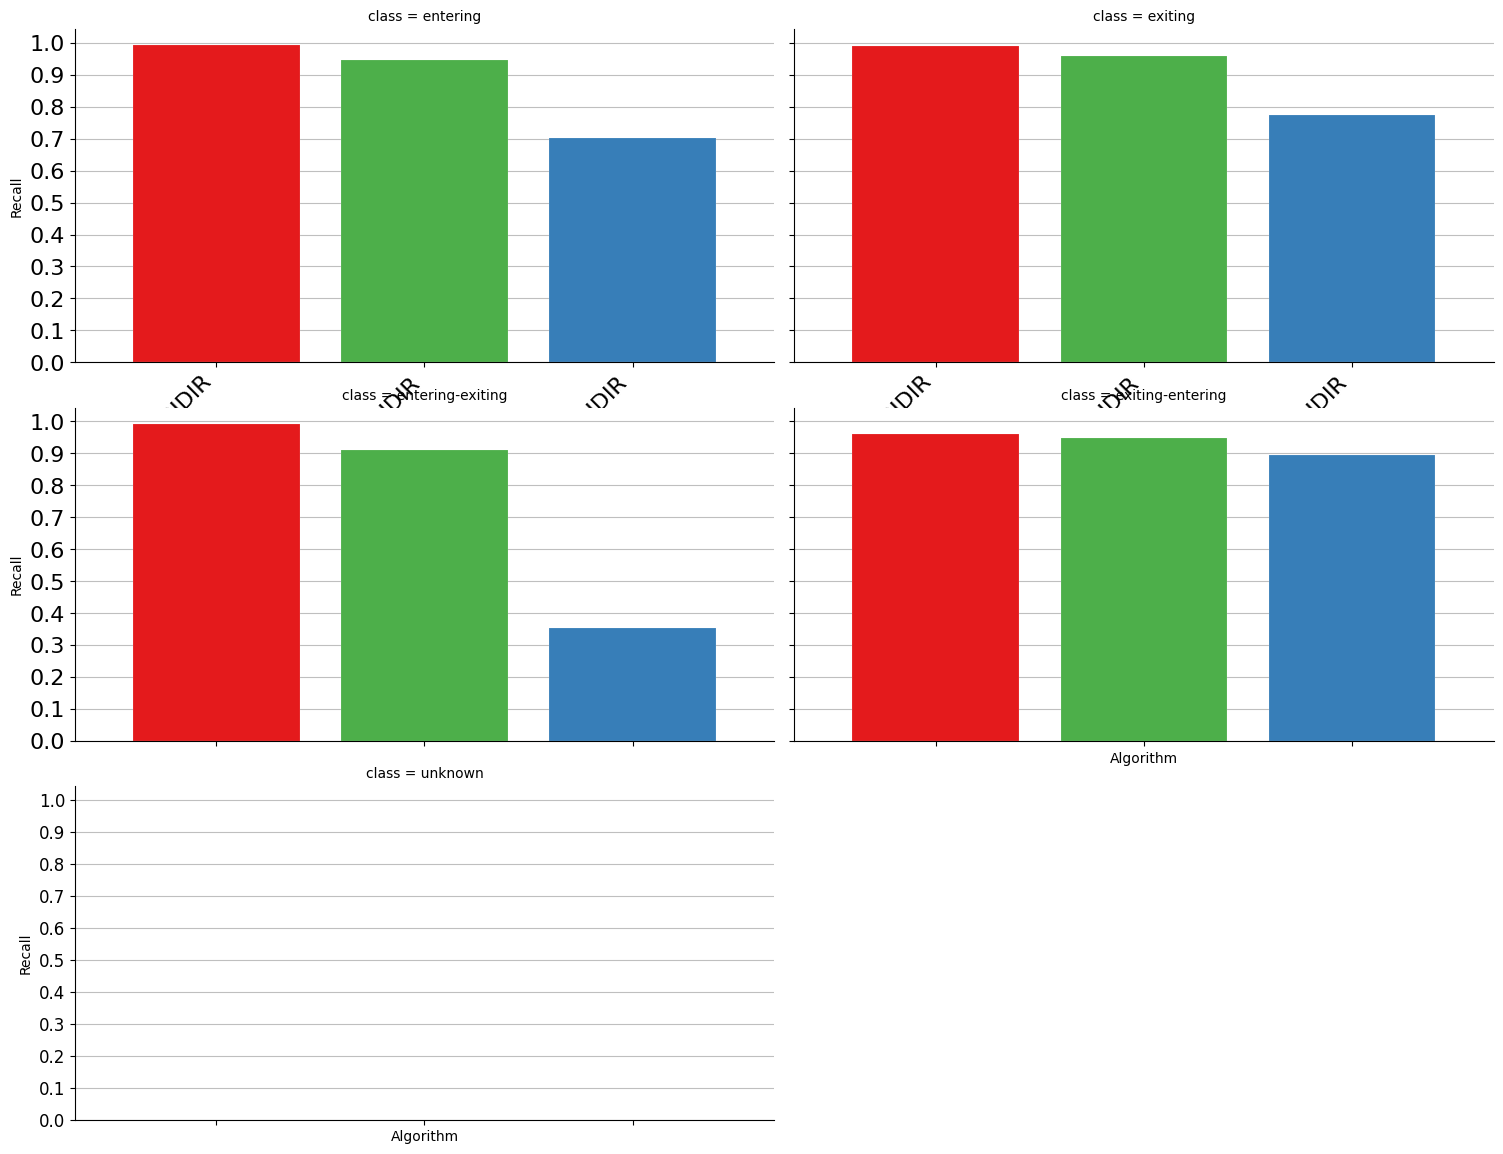

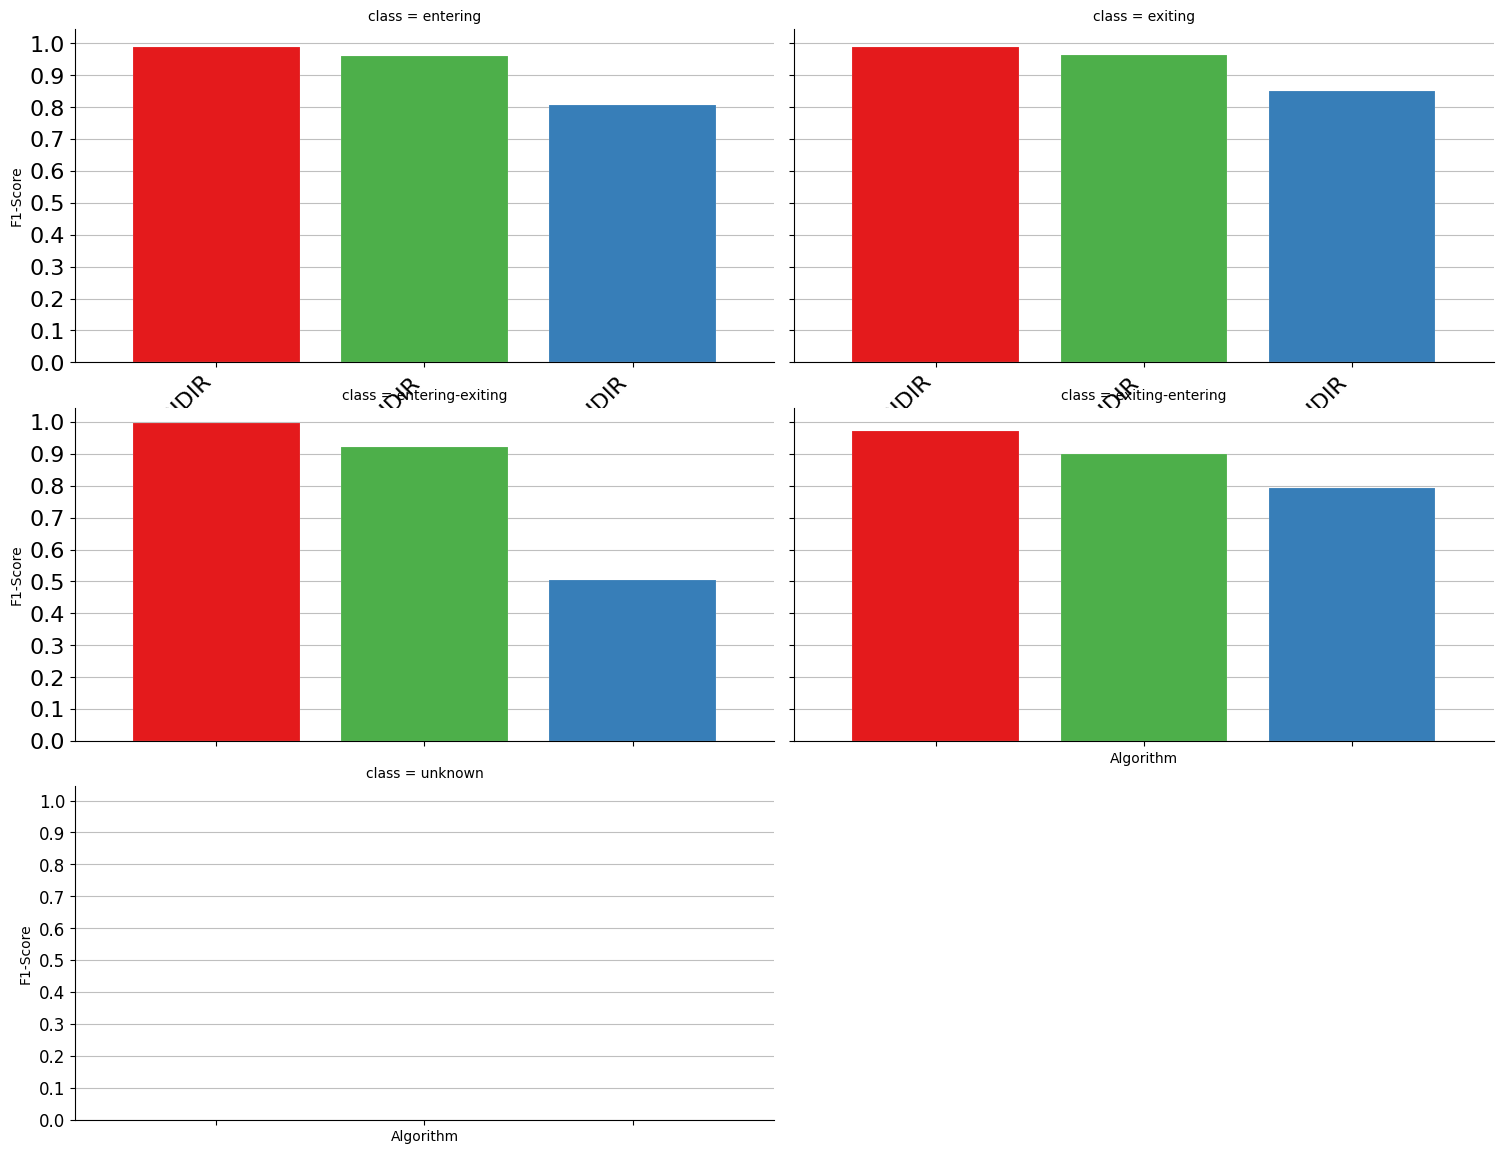

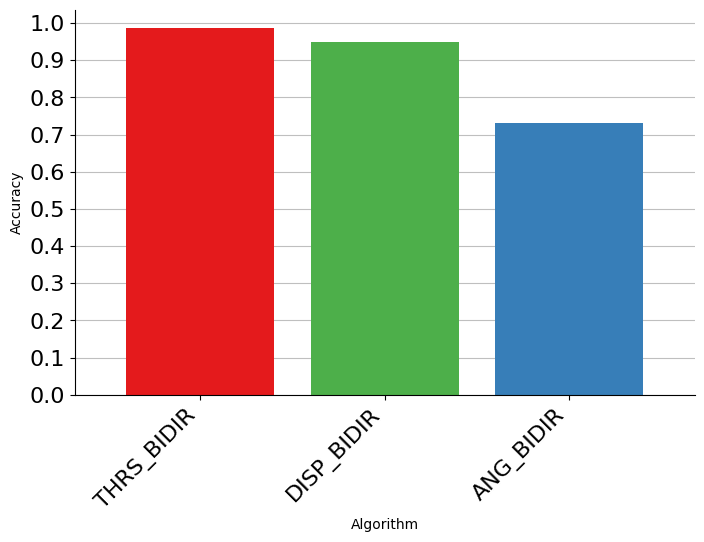

In [146]:
generate_graphs(compound_dict_copy,"compound")

C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\1029863662.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


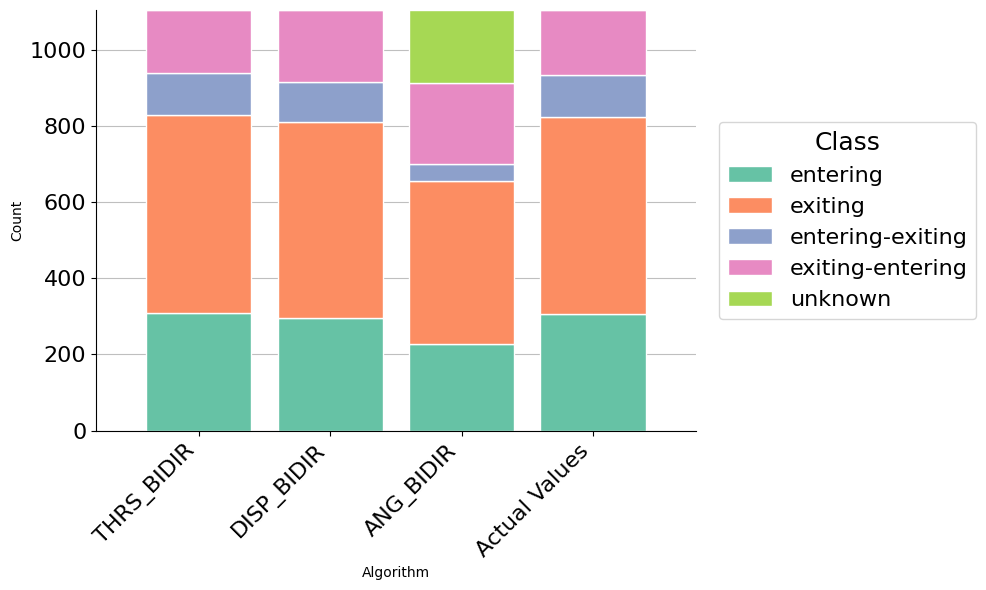

In [147]:
compound_matrix.rename(columns=shortened, inplace=True)
compound_matrix['Actual Values'] = cheatsheet['event']
generate_dist(compound_matrix,"compound")

## Global precision and accuracy

## GLOBAL ACCURACY

Considering only 3 classes (entering, exiting, unknown)

In [75]:
labels = ['entering','exiting','unknown']
cheatsheet_global3 = cheatsheet.replace(compound,'unknown')
global3_matrix = matrix.copy().replace(compound,'unknown')
score = calculate_scores(global3_matrix,cheatsheet_global3['event'],labels)
global3_dict = flatten_dict(score,labels)
global3_dict['algo'] = global3_dict['algo'].map(shortened) 
generateAcc(global3_matrix,cheatsheet_global3,labels)

C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\3230884626.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cheatsheet_global3 = cheatsheet.replace(compound,'unknown')
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.99      0.99      0.99       335
     exiting       1.00      0.99      0.99       545
     unknown       0.99      1.00      0.99       404

    accuracy                           0.99      1284
   macro avg       0.99      0.99      0.99      1284
weighted avg       0.99      0.99      0.99      1284

ACCURACY
0.9929906542056075
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.99      0.98      0.99       335
     exiting       0.99      0.99      0.99       545
     unknown       0.98      1.00      0.99       404

    accuracy                           0.99      1284
   macro avg       0.99      0.99      0.99      1284
weighted avg       0.99      0.99      0.99      1284

ACCURACY
0.9898753894080997
ANG_START_OLD
              precision    recall  f1-score   support

    entering       0.68      0.72      0.70       335
     exiting       0.65      0.98  

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [78]:
angle = 30

#read cheatsheet of all cases

cheatsheet = pd.read_csv("5seconds_20260406_234425.csv")
ambiguous = ['TRUE','x']
cheatsheet = cheatsheet[~cheatsheet['ambiguousflag'].isin(ambiguous)].dropna(subset=['event']).reset_index()
mapping = {'DU':'exiting-entering','UD':'entering-exiting','D':'exiting','U':'entering'}
cheatsheet['event'] = cheatsheet['event'].map(mapping)

#generate all classifications

labels = ['entering','exiting','entering-exiting','exiting-entering']
for_matrix = {}

functions = {
    'THRS_DOUBLE': in_out,
    'THRS_SINGLE': in_out_single,
    'DISP_START_END': displacementinit,
    'ANG_START_OLD': firstangleOLD,
    'ANG_END_OLD': lastangleOLD,
    'BEE_ANG_SUM': angles,
    'THRS_BIDIR':in_out2,
    'DISP_START': displacement2,
    'DISP_END': displacement,
    'BEE_ANG_START': firstangle,
    'BEE_ANG_END': lastangle,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}
functions = {k: functions[k] for k in algo_order if k in functions}

for APPROACHES, func in functions.items():
    for_matrix[APPROACHES] = []
    
for index, row in cheatsheet.iterrows():
    event = row['event']
    line = row['group_id']
    detections = vdf[vdf['group_id'] == line]

    unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix[APPROACHES].append(result)


matrix = pd.DataFrame.from_dict(for_matrix)

generateAcc(matrix,cheatsheet,labels)

labels = ['entering','exiting','unknown']
cheatsheet_global3 = cheatsheet.replace(compound,'unknown')
global3_matrix = matrix.copy().replace(compound,'unknown')
score = calculate_scores(global3_matrix,cheatsheet_global3['event'],labels)
global3_dict = flatten_dict(score,labels)
global3_dict['algo'] = global3_dict['algo'].map(shortened) 
generateAcc(global3_matrix,cheatsheet_global3,labels)

THRS_SINGLE
                  precision    recall  f1-score   support

        entering       0.99      0.99      0.99       335
         exiting       1.00      0.99      0.99       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

       micro avg       1.00      0.68      0.81      1284
       macro avg       0.50      0.50      0.50      1284
    weighted avg       0.68      0.68      0.68      1284

ACCURACY
0.6791277258566978
THRS_DOUBLE
                  precision    recall  f1-score   support

        entering       0.99      0.98      0.99       335
         exiting       0.99      0.99      0.99       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

       micro avg       0.99      0.68      0.81      1284
       macro avg       0.50      0.49      0.50      1284
    weighted avg       0.68      0.68      0.68      1284

ACCURACY
0.676

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

                  precision    recall  f1-score   support

        entering       0.66      0.95      0.78       335
         exiting       0.68      0.99      0.81       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

       micro avg       0.67      0.67      0.67      1284
       macro avg       0.34      0.49      0.40      1284
    weighted avg       0.46      0.67      0.55      1284

ACCURACY
0.6682242990654206
DISP_END
                  precision    recall  f1-score   support

        entering       0.56      0.98      0.72       335
         exiting       0.75      0.97      0.85       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

        accuracy                           0.67      1284
       macro avg       0.33      0.49      0.39      1284
    weighted avg       0.47      0.67      0.55      1284

ACCURACY
0.6666666666666666
T

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.99      0.99      0.99       335
     exiting       1.00      0.99      0.99       545
     unknown       0.99      1.00      0.99       404

    accuracy                           0.99      1284
   macro avg       0.99      0.99      0.99      1284
weighted avg       0.99      0.99      0.99      1284

ACCURACY
0.9929906542056075
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.99      0.98      0.99       335
     exiting       0.99      0.99      0.99       545
     unknown       0.98      1.00      0.99       404

    accuracy                           0.99      1284
   macro avg       0.99      0.99      0.99      1284
weighted avg       0.99      0.99      0.99      1284

ACCURACY
0.9898753894080997
ANG_START_OLD
              precision    recall  f1-score   support

    entering       0.69      0.61      0.64       335
     exiting       0.70      0.95  

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


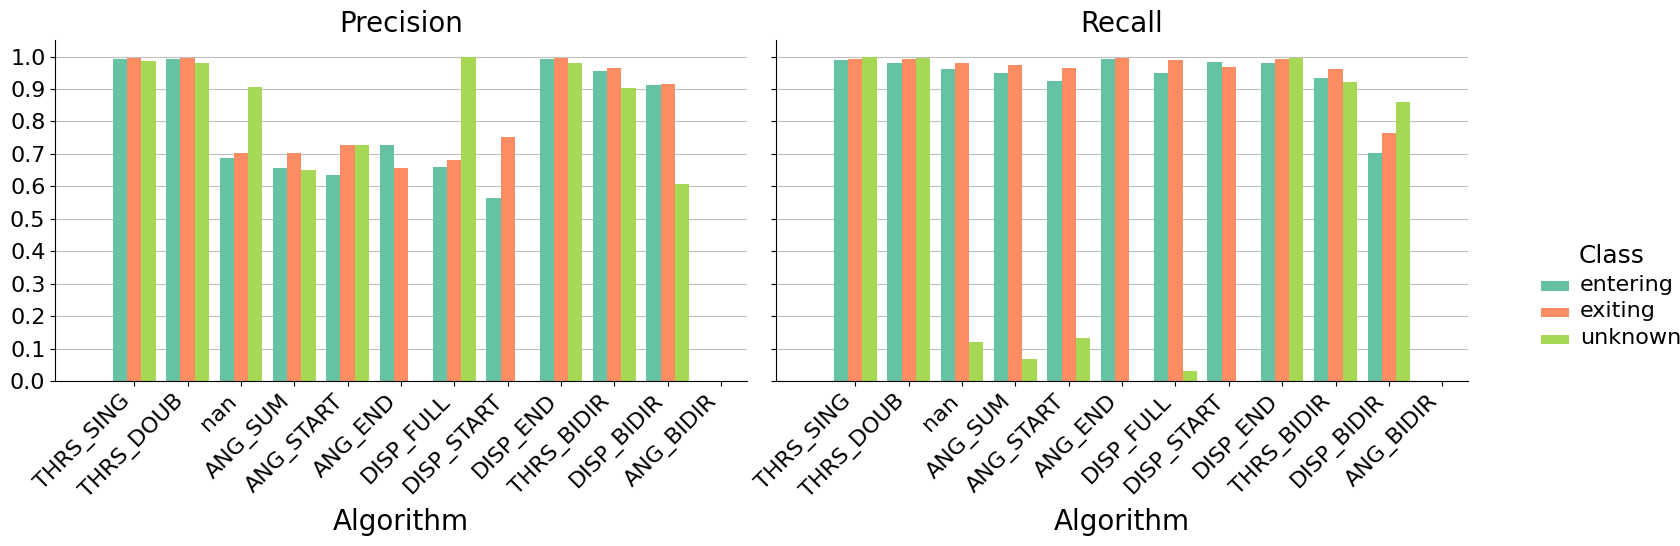

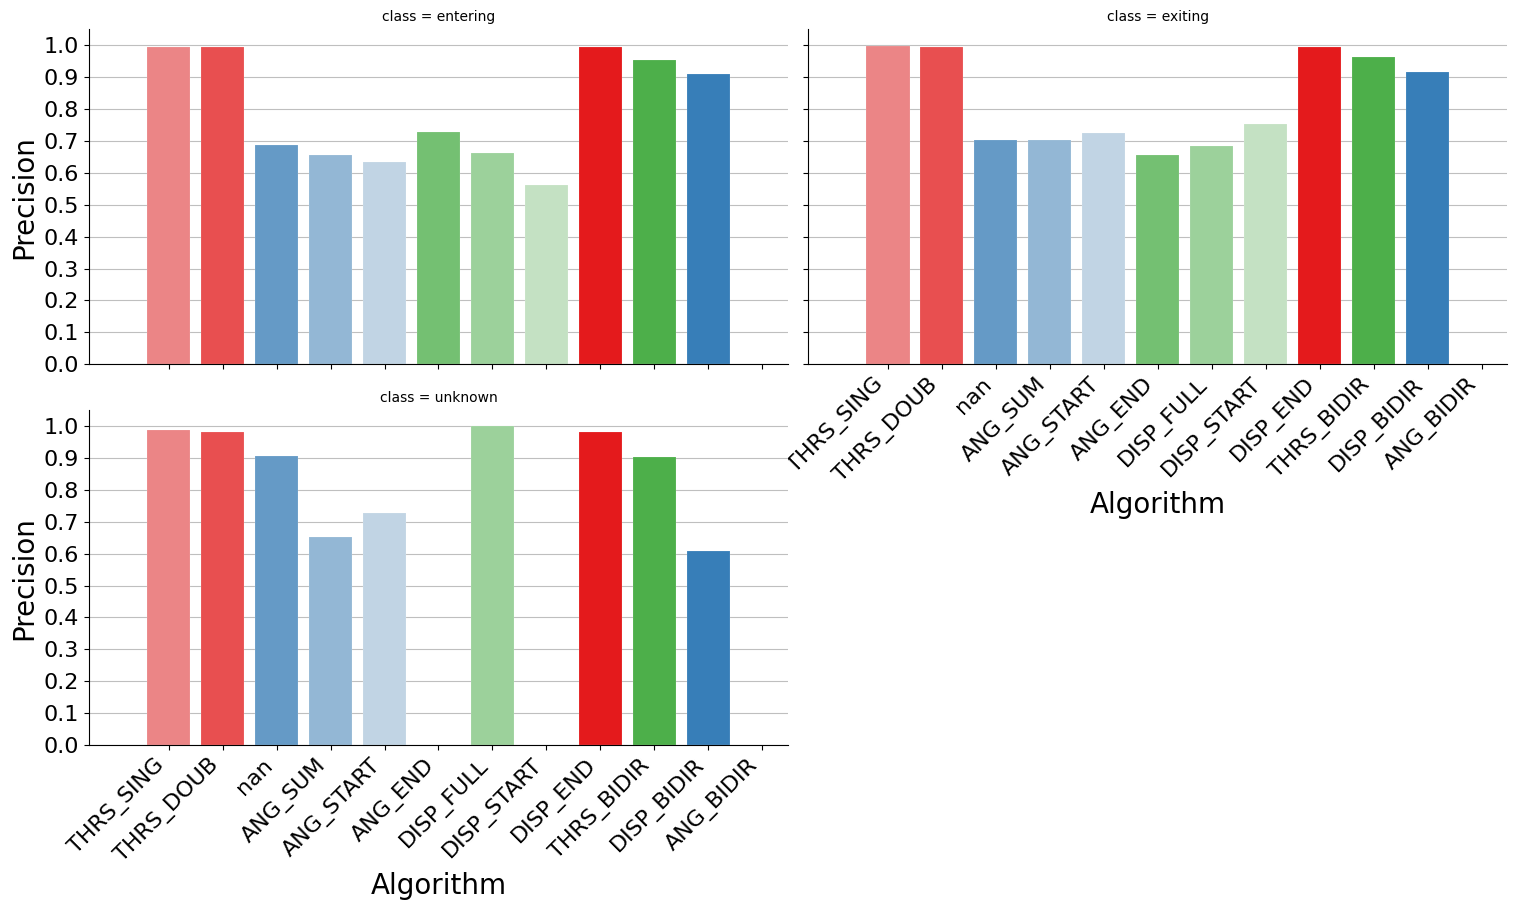

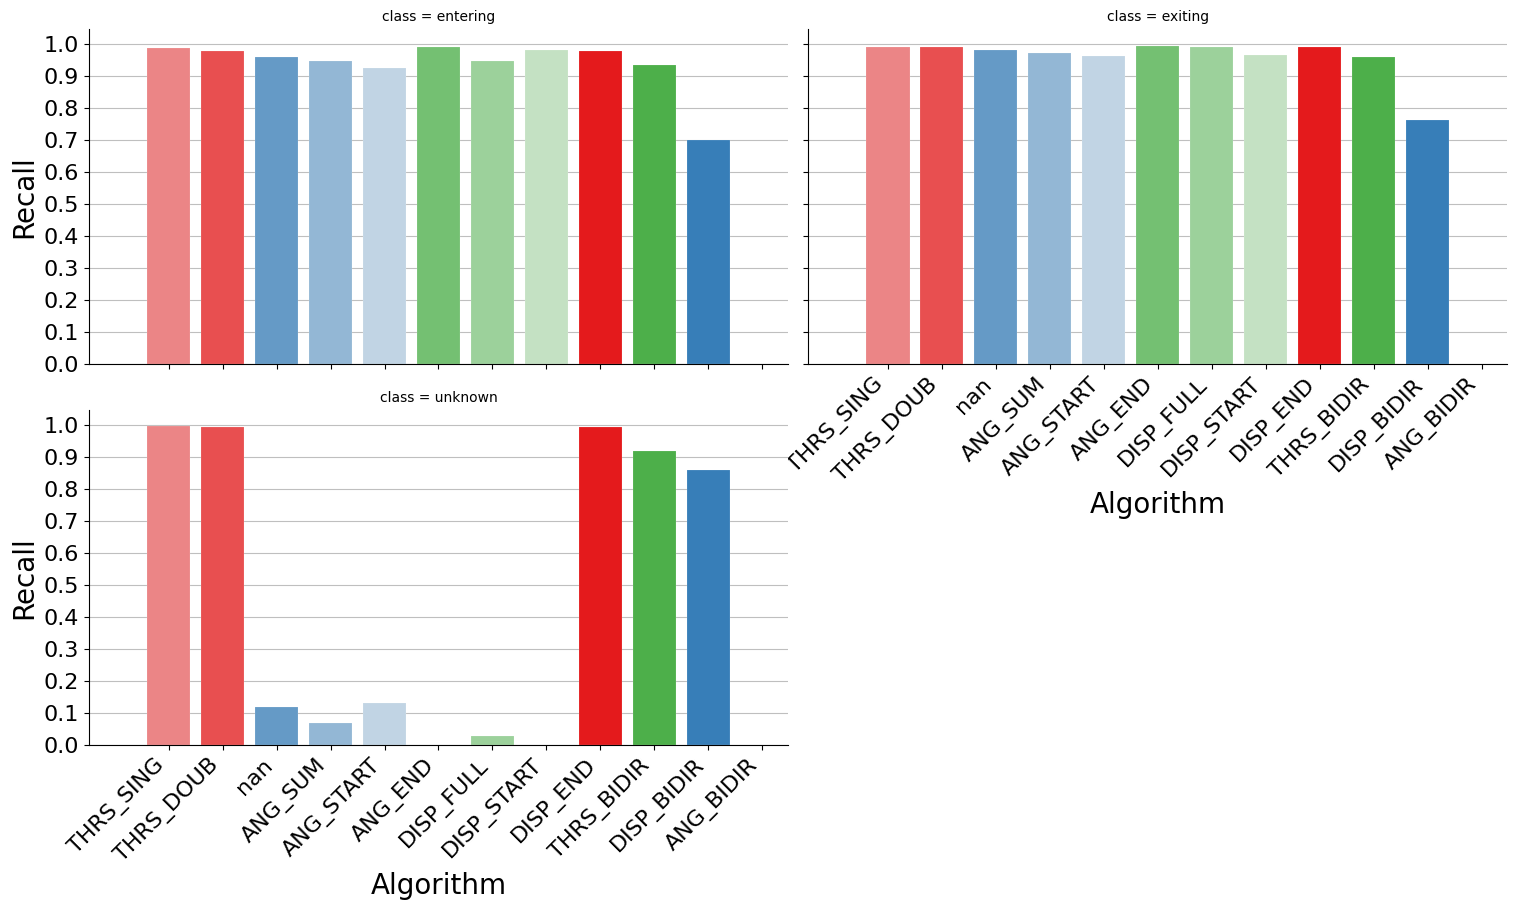

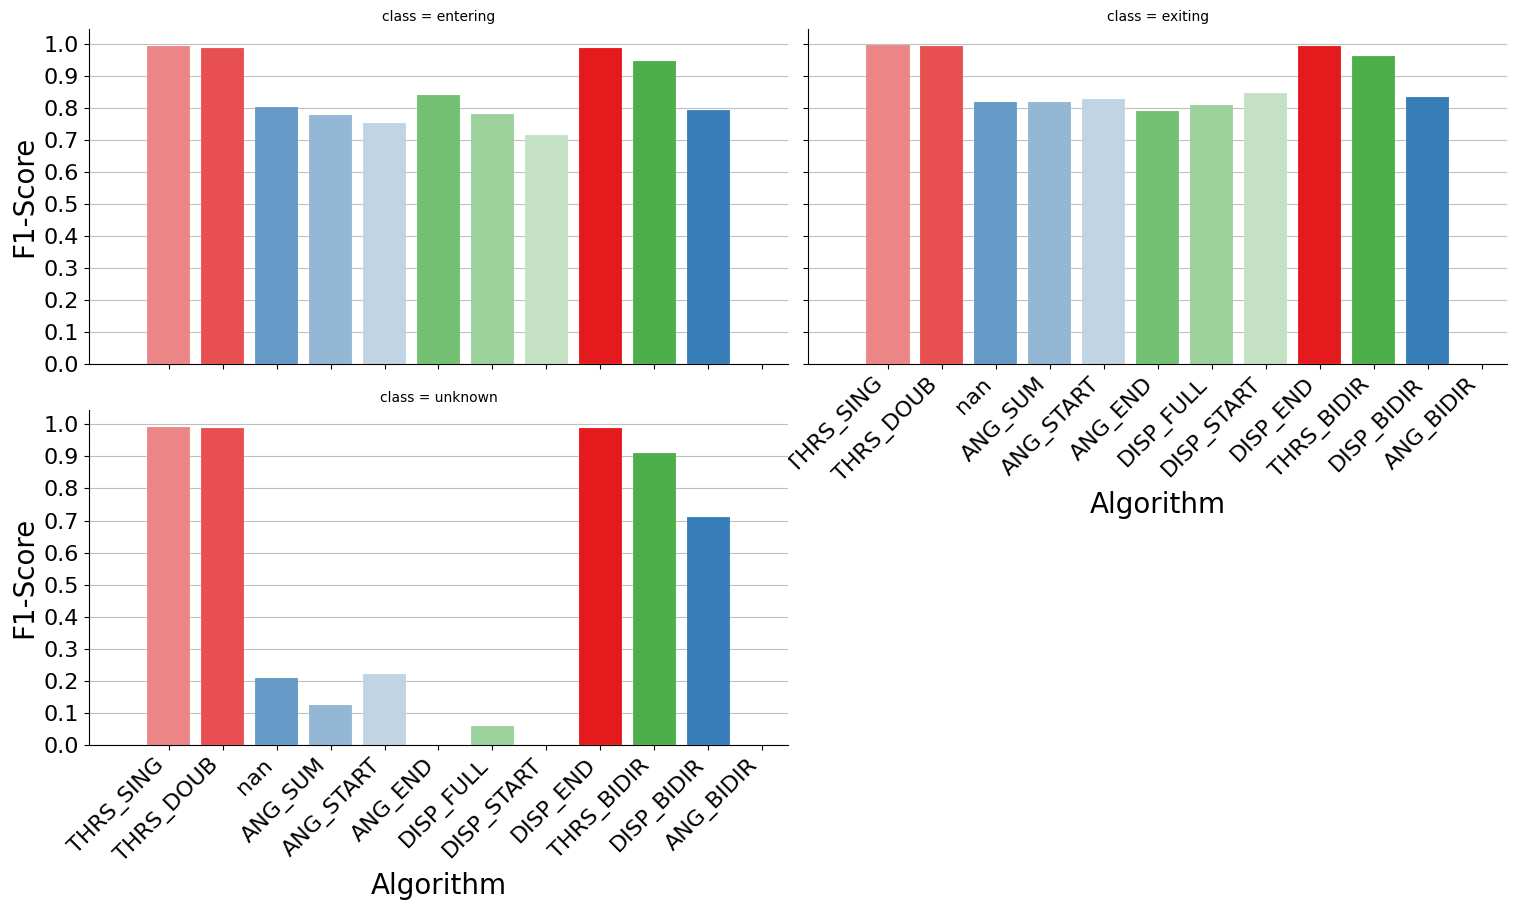

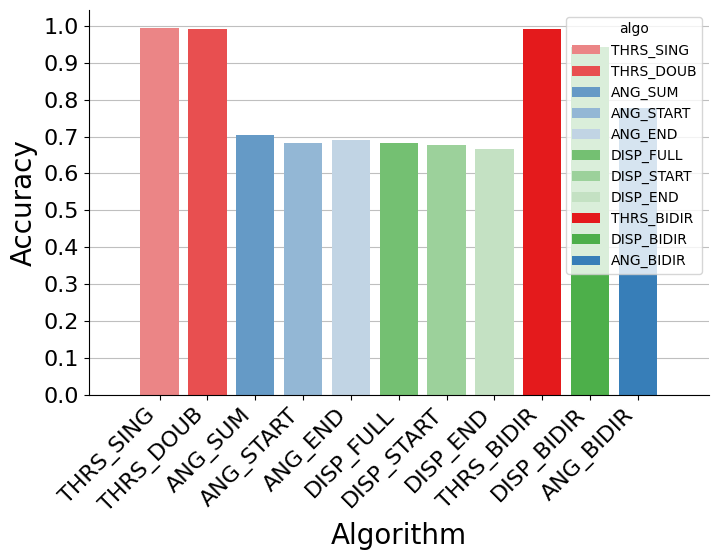

In [76]:
generate_sidegraphs(global3_dict,"global3")
generate_graphs(global3_dict,"global3")
global3_matrix.rename(columns=shortened, inplace=True)
global3_matrix['Actual Values'] = cheatsheet_global3['event']

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

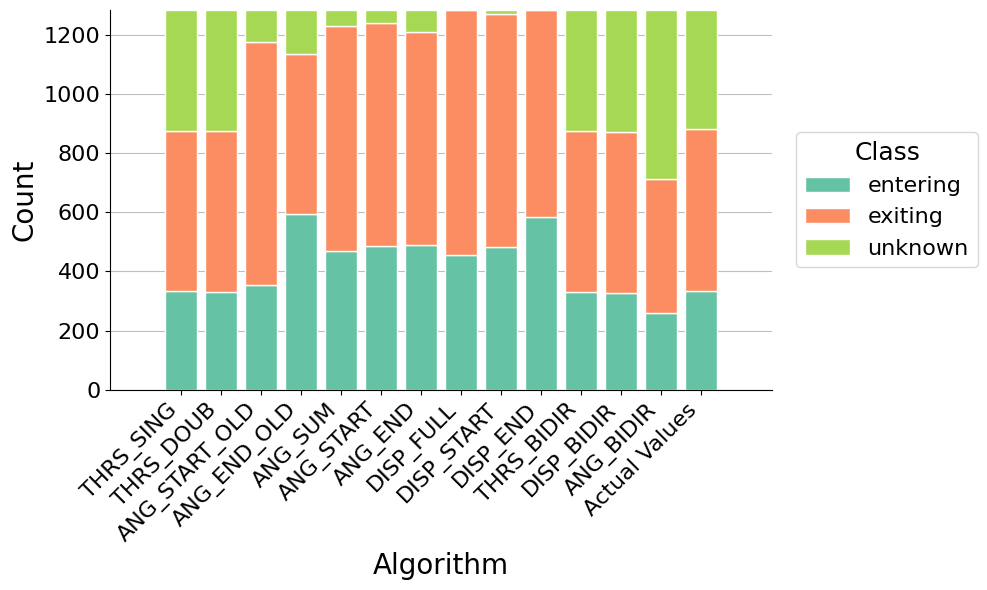

In [77]:
score = calculate_scores(global3_matrix,cheatsheet_global3['event'],labels)
global3_dict = flatten_dict(score,labels)
global3_dict['algo'] = global3_dict['algo'].map(shortened) 
generate_dist(global3_matrix,"global3")

Considering full U-turn classes

In [71]:
global_matrix = matrix.copy()
score = calculate_scores(global_matrix,cheatsheet['event'],labels)
global_dict = flatten_dict(score,labels)

C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
C:\Users\kashi\AppData\Local\Temp\ipykernel_44384\1062043689.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


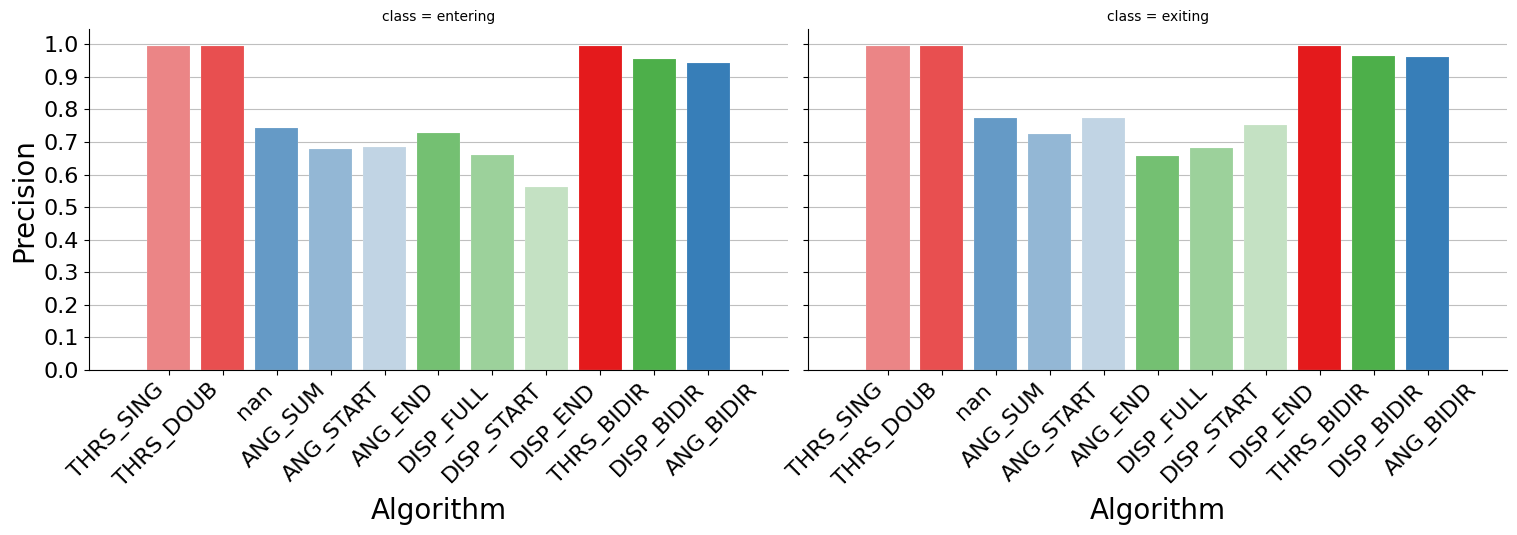

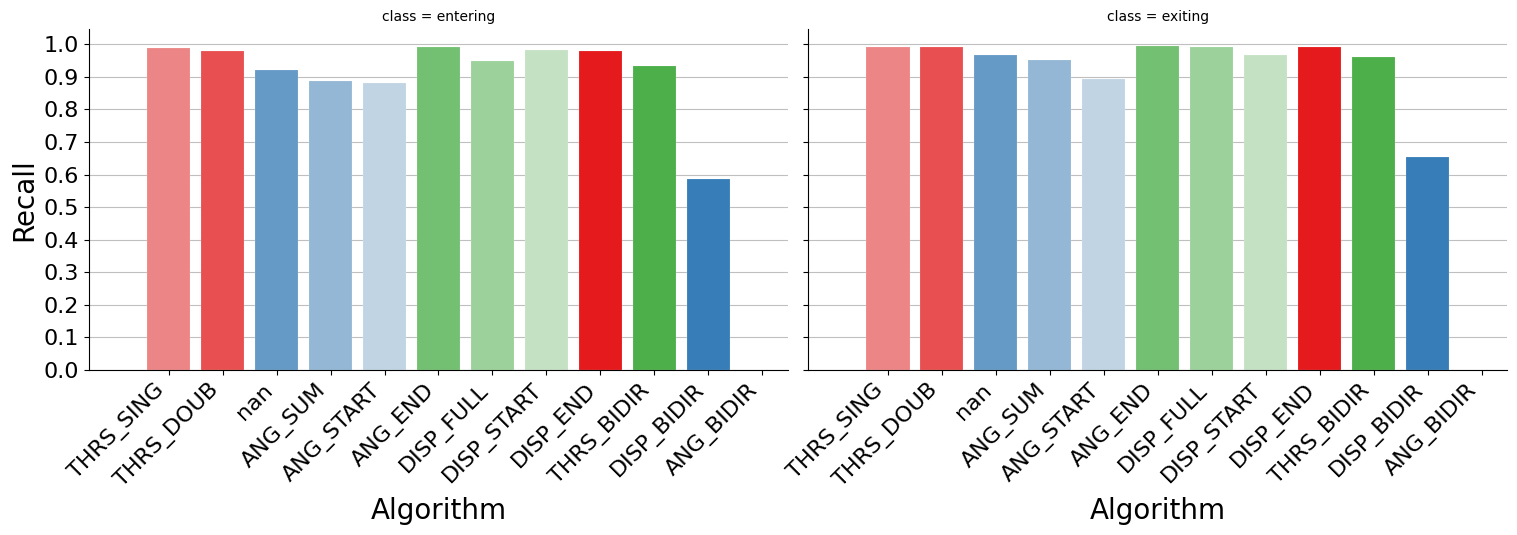

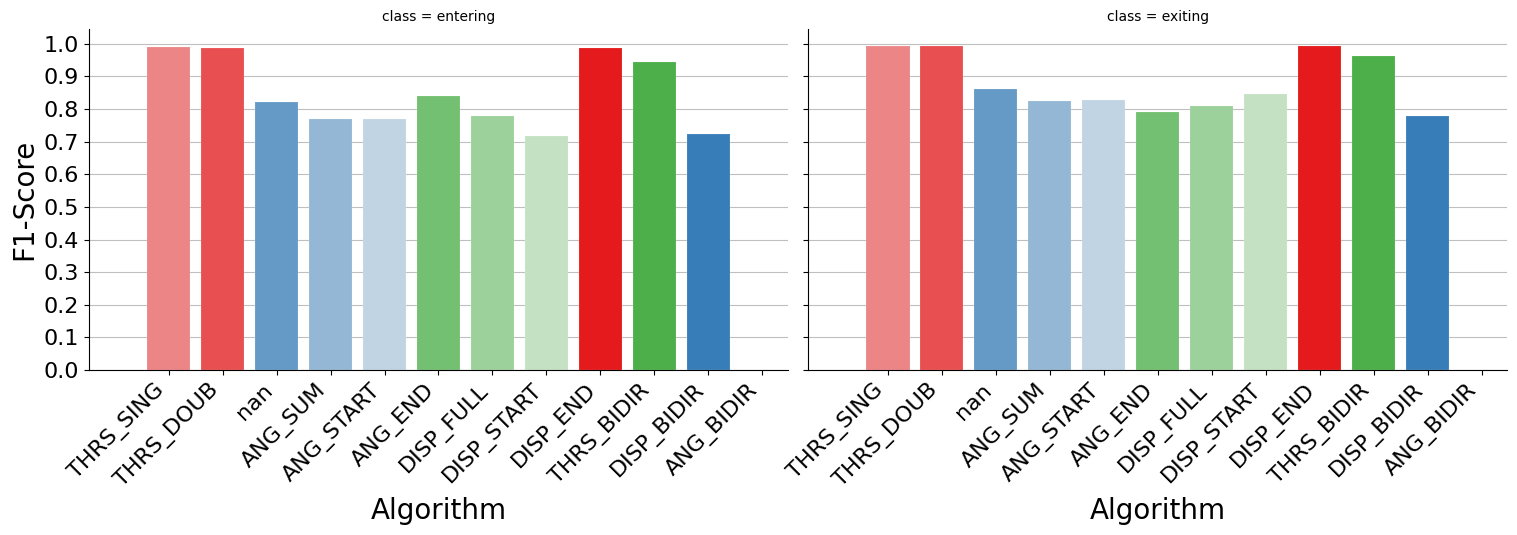

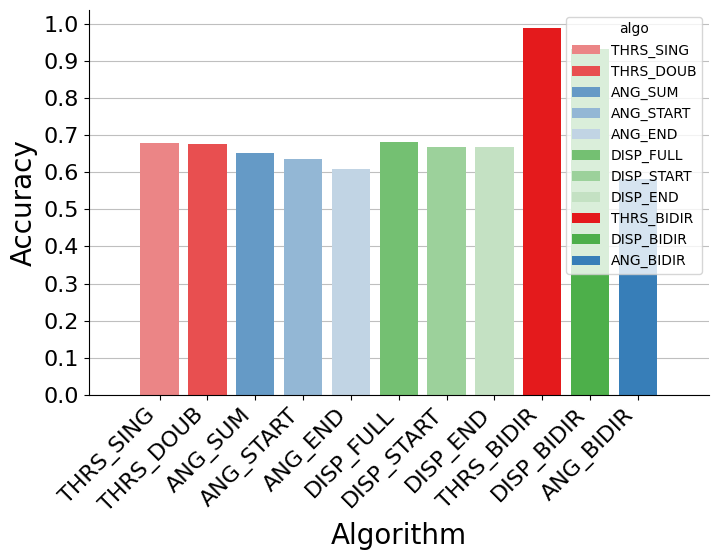

In [56]:
global_dict['algo'] = global_dict['algo'].map(shortened) 
generate_graphs(global_dict,"global")

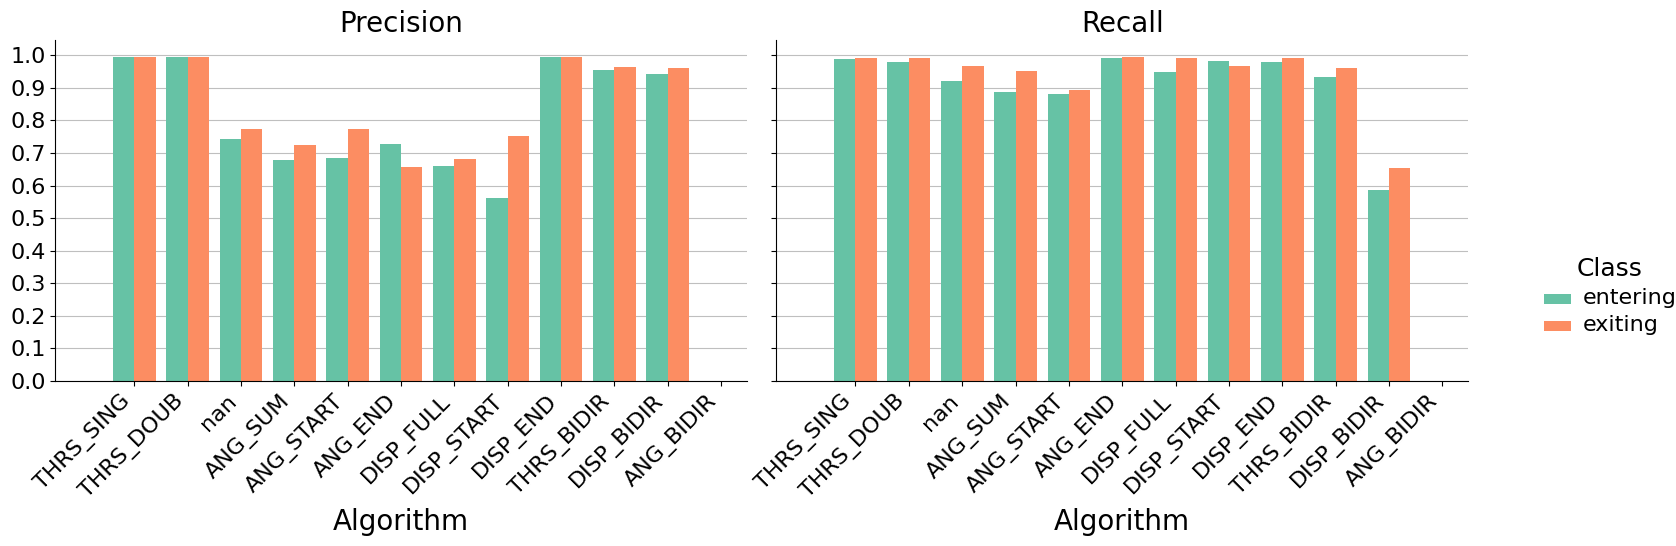

In [59]:
generate_sidegraphs(global_dict,"global")

In [154]:
global_matrix.rename(columns=shortened, inplace=True)
global_matrix['Actual Values'] = cheatsheet['event']

C:\Users\kashi\AppData\Local\Temp\ipykernel_25080\1029863662.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),horizontalalignment='right')


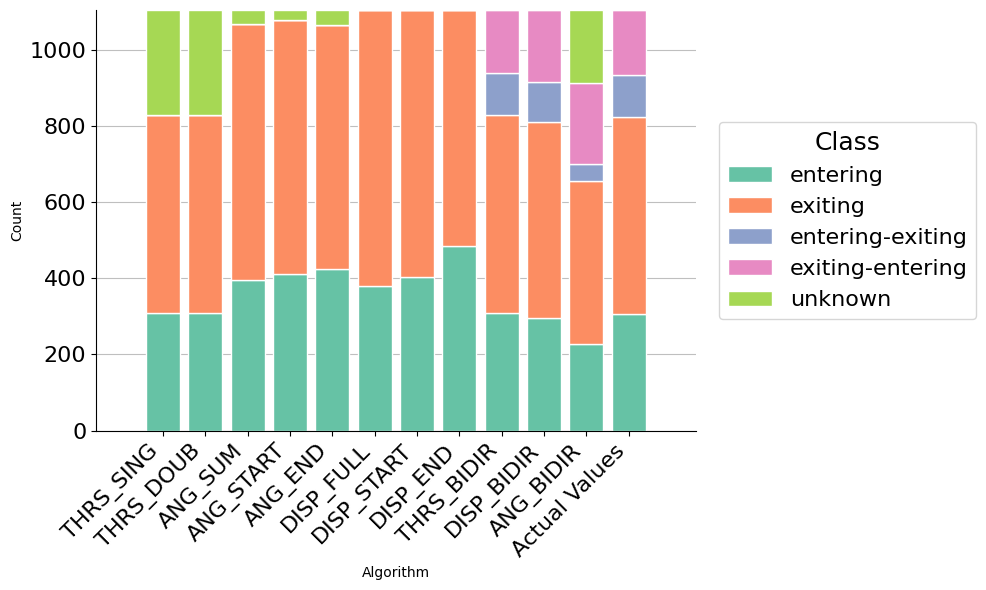

In [155]:
generate_dist(global_matrix,"global")

In [72]:
generateAcc(matrix,cheatsheet,labels)

THRS_SINGLE
              precision    recall  f1-score   support

    entering       0.99      0.99      0.99       335
     exiting       1.00      0.99      0.99       545

   micro avg       1.00      0.99      0.99       880
   macro avg       1.00      0.99      0.99       880
weighted avg       1.00      0.99      0.99       880

ACCURACY
0.6791277258566978
THRS_DOUBLE
              precision    recall  f1-score   support

    entering       0.99      0.98      0.99       335
     exiting       0.99      0.99      0.99       545

   micro avg       0.99      0.99      0.99       880
   macro avg       0.99      0.99      0.99       880
weighted avg       0.99      0.99      0.99       880

ACCURACY
0.676791277258567
ANG_START_OLD
              precision    recall  f1-score   support

    entering       0.69      0.61      0.64       335
     exiting       0.70      0.95      0.81       545

   micro avg       0.70      0.82      0.76       880
   macro avg       0.70      0.78  

In [74]:
angle = 10

#read cheatsheet of all cases

cheatsheet = pd.read_csv("5seconds_20260406_234425.csv")
ambiguous = ['TRUE','x']
cheatsheet = cheatsheet[~cheatsheet['ambiguousflag'].isin(ambiguous)].dropna(subset=['event']).reset_index()
mapping = {'DU':'exiting-entering','UD':'entering-exiting','D':'exiting','U':'entering'}
cheatsheet['event'] = cheatsheet['event'].map(mapping)

#generate all classifications

labels = ['entering','exiting','entering-exiting','exiting-entering']
for_matrix = {}

functions = {
    'THRS_DOUBLE': in_out,
    'THRS_SINGLE': in_out_single,
    'DISP_START_END': displacementinit,
    'ANG_START_OLD': firstangleOLD,
    'ANG_END_OLD': lastangleOLD,
    'BEE_ANG_SUM': angles,
    'THRS_BIDIR':in_out2,
    'DISP_START': displacement2,
    'DISP_END': displacement,
    'BEE_ANG_START': firstangle,
    'BEE_ANG_END': lastangle,
    'DISP_BIDIR': displacementbackforth,
    'BEE_ANG_BIDIR': lastfirstangle  
}
functions = {k: functions[k] for k in algo_order if k in functions}

for APPROACHES, func in functions.items():
    for_matrix[APPROACHES] = []
    
for index, row in cheatsheet.iterrows():
    event = row['event']
    line = row['group_id']
    detections = vdf[vdf['group_id'] == line]

    unknowns = ['unknown-entering','unknown-exiting','exiting-unknown','entering-unknown']
    for APPROACHES, func in functions.items():
        result = func(detections)
        if result in unknowns:
            result = 'unknown'
        for_matrix[APPROACHES].append(result)


matrix = pd.DataFrame.from_dict(for_matrix)

generateAcc(matrix,cheatsheet,labels)

THRS_SINGLE
                  precision    recall  f1-score   support

        entering       0.99      0.99      0.99       335
         exiting       1.00      0.99      0.99       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

       micro avg       1.00      0.68      0.81      1284
       macro avg       0.50      0.50      0.50      1284
    weighted avg       0.68      0.68      0.68      1284

ACCURACY
0.6791277258566978
THRS_DOUBLE
                  precision    recall  f1-score   support

        entering       0.99      0.98      0.99       335
         exiting       0.99      0.99      0.99       545
entering-exiting       0.00      0.00      0.00       180
exiting-entering       0.00      0.00      0.00       224

       micro avg       0.99      0.68      0.81      1284
       macro avg       0.50      0.49      0.50      1284
    weighted avg       0.68      0.68      0.68      1284

ACCURACY
0.676

C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kashi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [79]:
cheatsheet['event'].value_counts()

event
exiting             545
entering            335
exiting-entering    224
entering-exiting    180
Name: count, dtype: int64

In [157]:
len(cheatsheet)

1104

In [158]:
len(vdf.groupby(['video_name','track_id','track_tagid']))

2372

In [149]:
gt_map = cheatsheet.set_index('group_id')['event'].to_dict()

vdf = vdf[vdf['group_id'].isin(cheatsheet['group_id'].unique())]

rows = []

for k, detections in vdf.groupby('group_id', sort=False):
    dt = detections['track_endtime'].iloc[-1]
    tag_id = detections['track_tagid'].iloc[-1]

    rows.append({
        'group_id': k,
        'tagID': tag_id,
        'datetime': dt,
        'anglesingle_event': angles(detections),
        'thrs_bidir_event': in_out2(detections),
        'displacement_event': displacement(detections),
        'groundtruth_event': gt_map.get(k)
    })

results = pd.DataFrame(rows)

In [150]:
results.drop(['group_id'], axis=1,inplace=True)
results

,tagID,datetime,anglesingle_event,thrs_bidir_event,displacement_event,groundtruth_event
0,2129,2019-08-07 11:00:41.600,exiting,exiting-entering,entering,exiting-entering
1,259,2019-08-07 11:01:37.350,exiting,exiting,exiting,exiting
2,693,2019-08-07 11:01:58.550,unknown,exiting-entering,entering,exiting
3,2364,2019-08-07 11:02:07.700,entering,entering-exiting,exiting,entering-exiting
4,693,2019-08-07 11:02:30.700,exiting,exiting,exiting,entering
...,...,...,...,...,...,...
1116,420,2019-08-08 16:54:12.650,entering,entering,entering,entering
1117,799,2019-08-08 16:56:48.350,exiting,exiting,exiting,exiting
1118,922,2019-08-08 16:57:12.700,exiting,exiting,exiting,exiting
1119,575,2019-08-08 16:58:35.650,exiting,exiting,exiting,exiting


In [158]:
results.drop(list(results)[3:], axis=1).to_csv("angles.csv",index=False)

In [159]:
results.drop(results.columns[[2,4,5]], axis=1).to_csv("thrs_bidir.csv",index=False)

In [160]:
results.drop(results.columns[[2,3,5]], axis=1).to_csv("disp.csv",index=False)

In [161]:
results.drop(results.columns[[2,3,4]], axis=1).to_csv("gt.csv",index=False)